# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [44]:
# =============================
# Useful Imports
# =============================
!pip install -r requirements.txt

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

# Kaggle and Progress Tracking
#from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42
RANDOM_STATE = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [5]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

Zillow would be most interested in having accurate models for its "Zestimate". The better predictions for a Zestimate leads to more trust in the site and company overall. In addition to the Zestimate, Zillow estimates other financial information about a house including property tax assessments and mortgage rates. These estimates are critical to a buyers monthly payment and can increase site traffic and visit time if all of these periphery numbers are as high quality as possible. 

**1.2:**  How will your solution be used?

Our solution for being able to predict a property's tax value assessment would be most useful towards these periphery calculations. A customer can view this value as part of a Zestimate and monthly payment estimate. For most people, the monthly payment is the key indicator of financial affordability.

Also, on the Zillow site you are able to view previous tax property payments and assessments scraped from available public data. Our tax value predictions can be compared with the publicly accessed data to flag any potential data scraping errors. 

**1.3:**  How should success (or failure) be measured?

In addition to achieving quality prediction on our test data, to be successful the model should be accurately able to predict new, unseen, data. i.e, we can measure the root mean square error between the model's predictions and the new, unseen data, is within our preferred margin of error. 

For success as a Data Analyst Team, we hope that our model make it to production and is implemented on the Zillow website.  

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [6]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  finishedsqua

In [8]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [9]:
info_df = pd.DataFrame({
    "non_null": df.notnull().sum(),
    "null": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2),
    "nunique": df.nunique(),
     "dtype": df.dtypes,
})
display(info_df)
print(f"\nShape: {df.shape}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Dtypes: {dict(df.dtypes.value_counts())}")

,non_null,null,null_pct,nunique,dtype
parcelid,77613,0,0.00,77414,int64
airconditioningtypeid,25007,52606,67.78,5,float64
architecturalstyletypeid,207,77406,99.73,5,float64
basementsqft,50,77563,99.94,43,float64
bathroomcnt,77579,34,0.04,22,float64
bedroomcnt,77579,34,0.04,16,float64
buildingclasstypeid,15,77598,99.98,2,float64
buildingqualitytypeid,49809,27804,35.82,12,float64
calculatedbathnbr,76963,650,0.84,21,float64
decktypeid,614,76999,99.21,1,float64



Shape: (77613, 55)
Memory: 46.3 MB
Dtypes: {dtype('float64'): np.int64(49), <StringDtype(storage='python', na_value=nan)>: np.int64(3), dtype('O'): np.int64(2), dtype('int64'): np.int64(1)}


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

There are 24 categorical features. Although many are stored as float64 in the CSV, features like fips, regionidcounty, and heatingorsystemtypeid are lookup codes where the numeric value has no mathematical meaning — fips 6037 is not "greater than" 6059. The full list: ['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid', 'buildingqualitytypeid', 'decktypeid', 'fips', 'hashottuborspa', 'heatingorsystemtypeid', 'poolcnt', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'storytypeid', 'typeconstructiontypeid', 'fireplaceflag', 'taxdelinquencyflag'].

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

Parcelid is an arbitrary identifier with no predictive meaning. rawcensustractandblock and censustractandblock are raw geographic codes that largely overlap with the regionid* columns and fips, as confirmed by the redundancy analysis (correlation of 1.0 between rawcensustractandblock and fips). assessmentyear has a single value of 2016 across all rows, contributing zero variance. Beyond these, the redundancy report reveals that the 7 square-footage variants contain multiple pairs with >0.95 correlation, and the 4 bathroom columns show similar duplication — keeping all of them would introduce multicollinearity without new information.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Twenty features exceed 90% missing values. The most extreme cases — buildingclasstypeid (99.98%), finishedsquarefeet13 (99.95%), storytypeid (99.94%), and basementsqft (99.94%) — have fewer than 50 non-null values out of 77,613 rows, making any imputation strategy unreliable. A second tier (92–99% missing) includes finishedsquarefeet6, pooltypeid10, decktypeid, and poolsizesum. However, some high-missing columns like poolcnt and fireplaceflag are binary presence/absence flags where the nullity itself is the signal, so they should not be dismissed purely on missing percentage.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

assessmentyear is the only truly zero-variance feature (all 77,579 non-null values are 2016). Nine columns appear to have just 1 unique value (decktypeid, hashottuborspa, poolcnt, pooltypeid10, pooltypeid2, pooltypeid7, storytypeid, fireplaceflag, taxdelinquencyflag) but these are binary-flag columns where the single value (e.g., poolcnt = 1.0) indicates presence and NaN indicates absence. The information is encoded in nullity, not the value itself. For these, converting to a 0/1 has-feature column would recover useful signal. The decktypeid (all values = 66 when present, 99.2% null) is the least useful of this group given its extreme sparsity.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

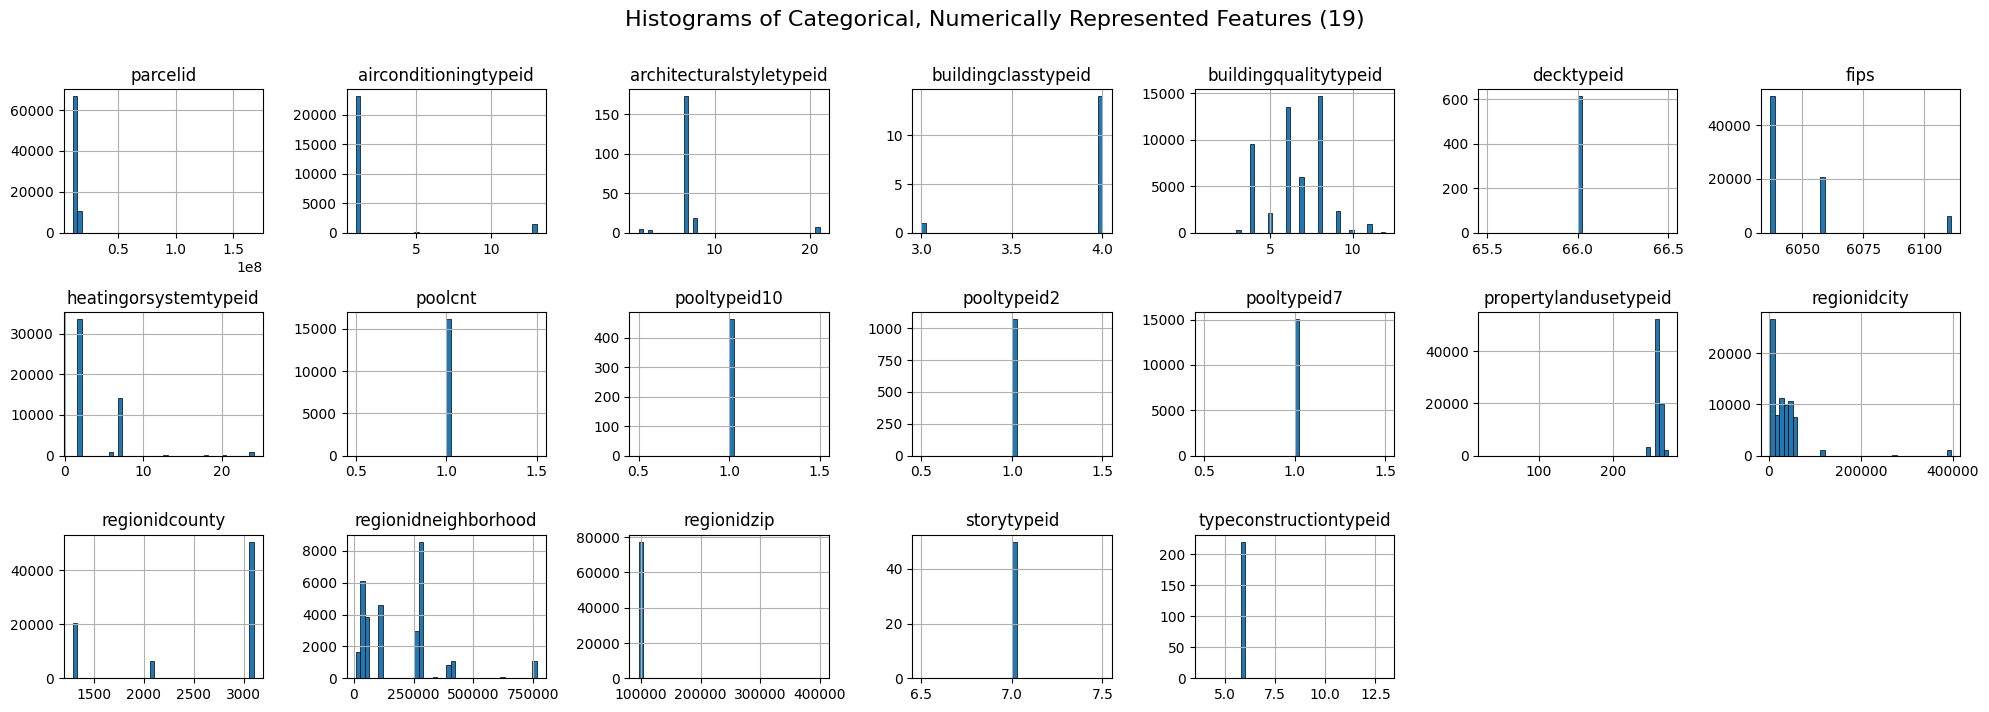

In [10]:
# Categorical histograms for non-objects:

categorical = ['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid', 'buildingqualitytypeid', 'decktypeid', 'fips', 'hashottuborspa', 'heatingorsystemtypeid', 'poolcnt', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'storytypeid', 'typeconstructiontypeid', 'fireplaceflag', 'taxdelinquencyflag']

fig = df[categorical].hist(figsize=(20, 7), layout=(-1, 7), bins=40, edgecolor='black', linewidth=0.5)
plt.suptitle("Histograms of Categorical, Numerically Represented Features (19)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Non-boolean features**: parcelid, airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, buildingqualitytypeid, fips, heatingorsystemtypeid, propertylandusetypeid, regionidcity, regionidcounty, regionidneighborhood, regionidzip

- Most non-boolean categorical features have extremely skewed distributions, with one dominant value making up 80%+ of all entries (e.g., airconditioningtypeid is overwhelmingly value 1, heatingorsystemtypeid is dominated by value 2).
- regionidcity and regionidneighborhood have relatively flat distributions across many unique values, suggesting they capture genuine geographic variation.
- propertycountylandusecode is heavily dominated by a few codes, with a long tail of rare codes.

**Boolean**: poolcnt, pooltypeid10, pooltypeid2, pooltypeid7

- Boolean but odd format: decktypeid and storytypeid look boolean but are marked at 66 and 7 instead of 1. This likely reflects encoding from the original data source rather than a meaningful numeric scale.
- All 5 object-type categorical columns (hashottuborspa, propertycountylandusecode, propertyzoningdesc, fireplaceflag, taxdelinquencyflag) are extremely sparse — most rows are NaN with a single non-null value type.

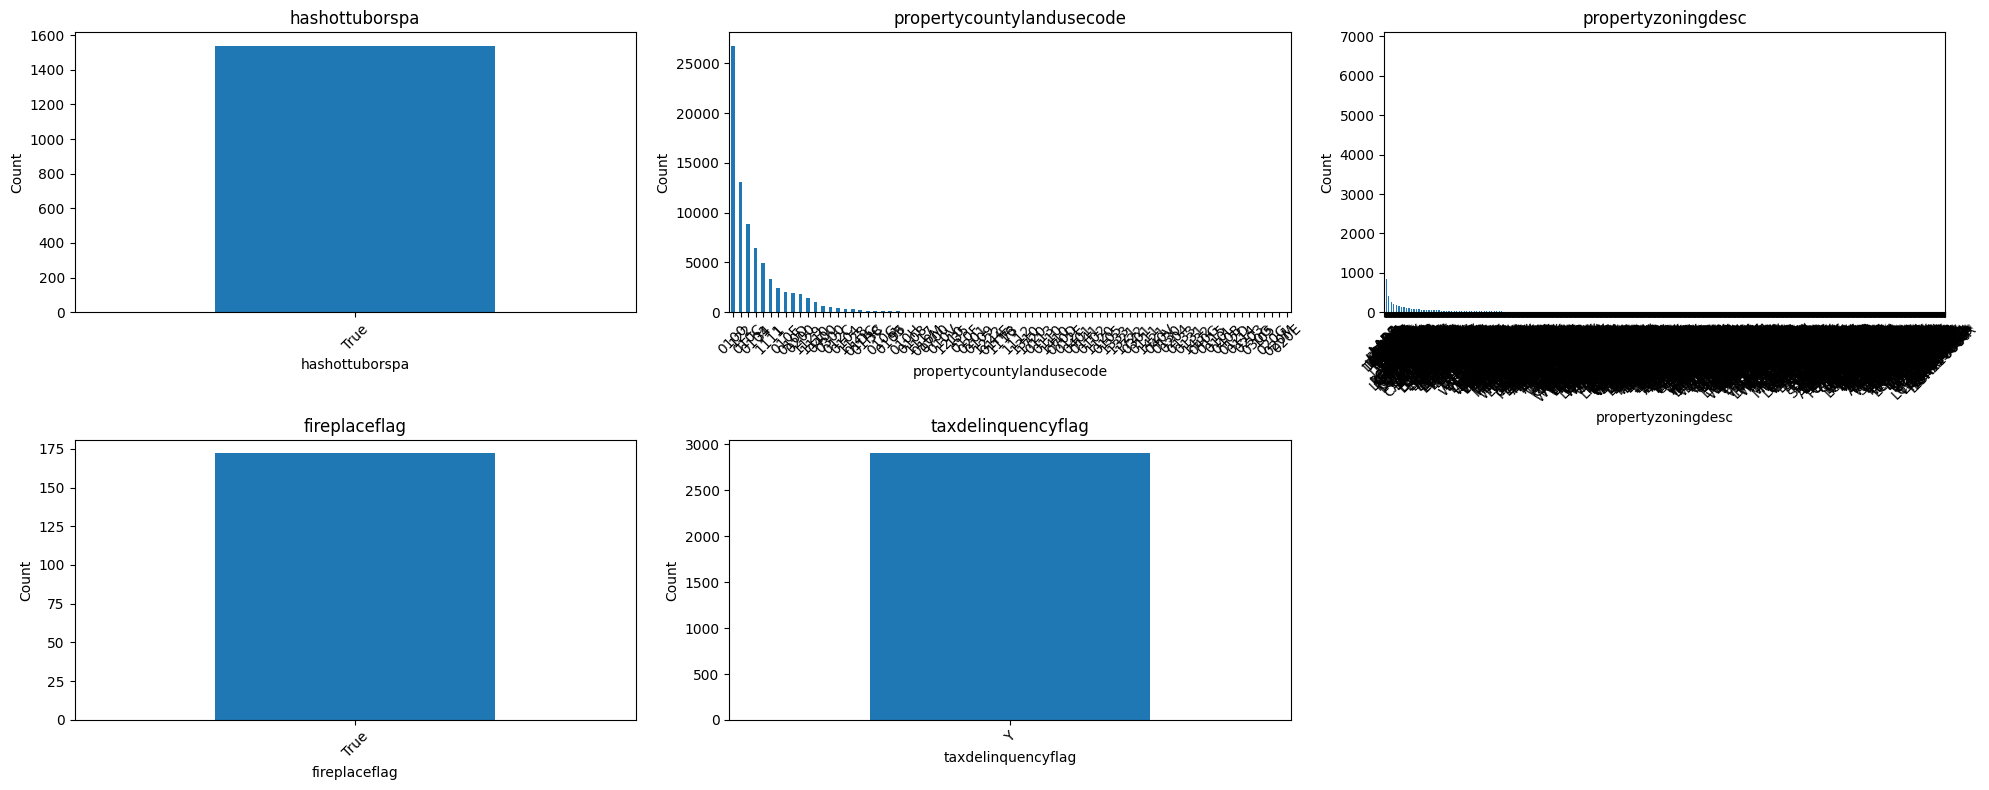

In [11]:
# Categorical bar plots for objects:

# data:
forbar = ['hashottuborspa','propertycountylandusecode','propertyzoningdesc','fireplaceflag','taxdelinquencyflag']


# plot:
n = len(forbar)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()
for i, col in enumerate(forbar):
    df[col].value_counts().plot(kind='bar', ax=axes[i], title=col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
# hide unused subplots:
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

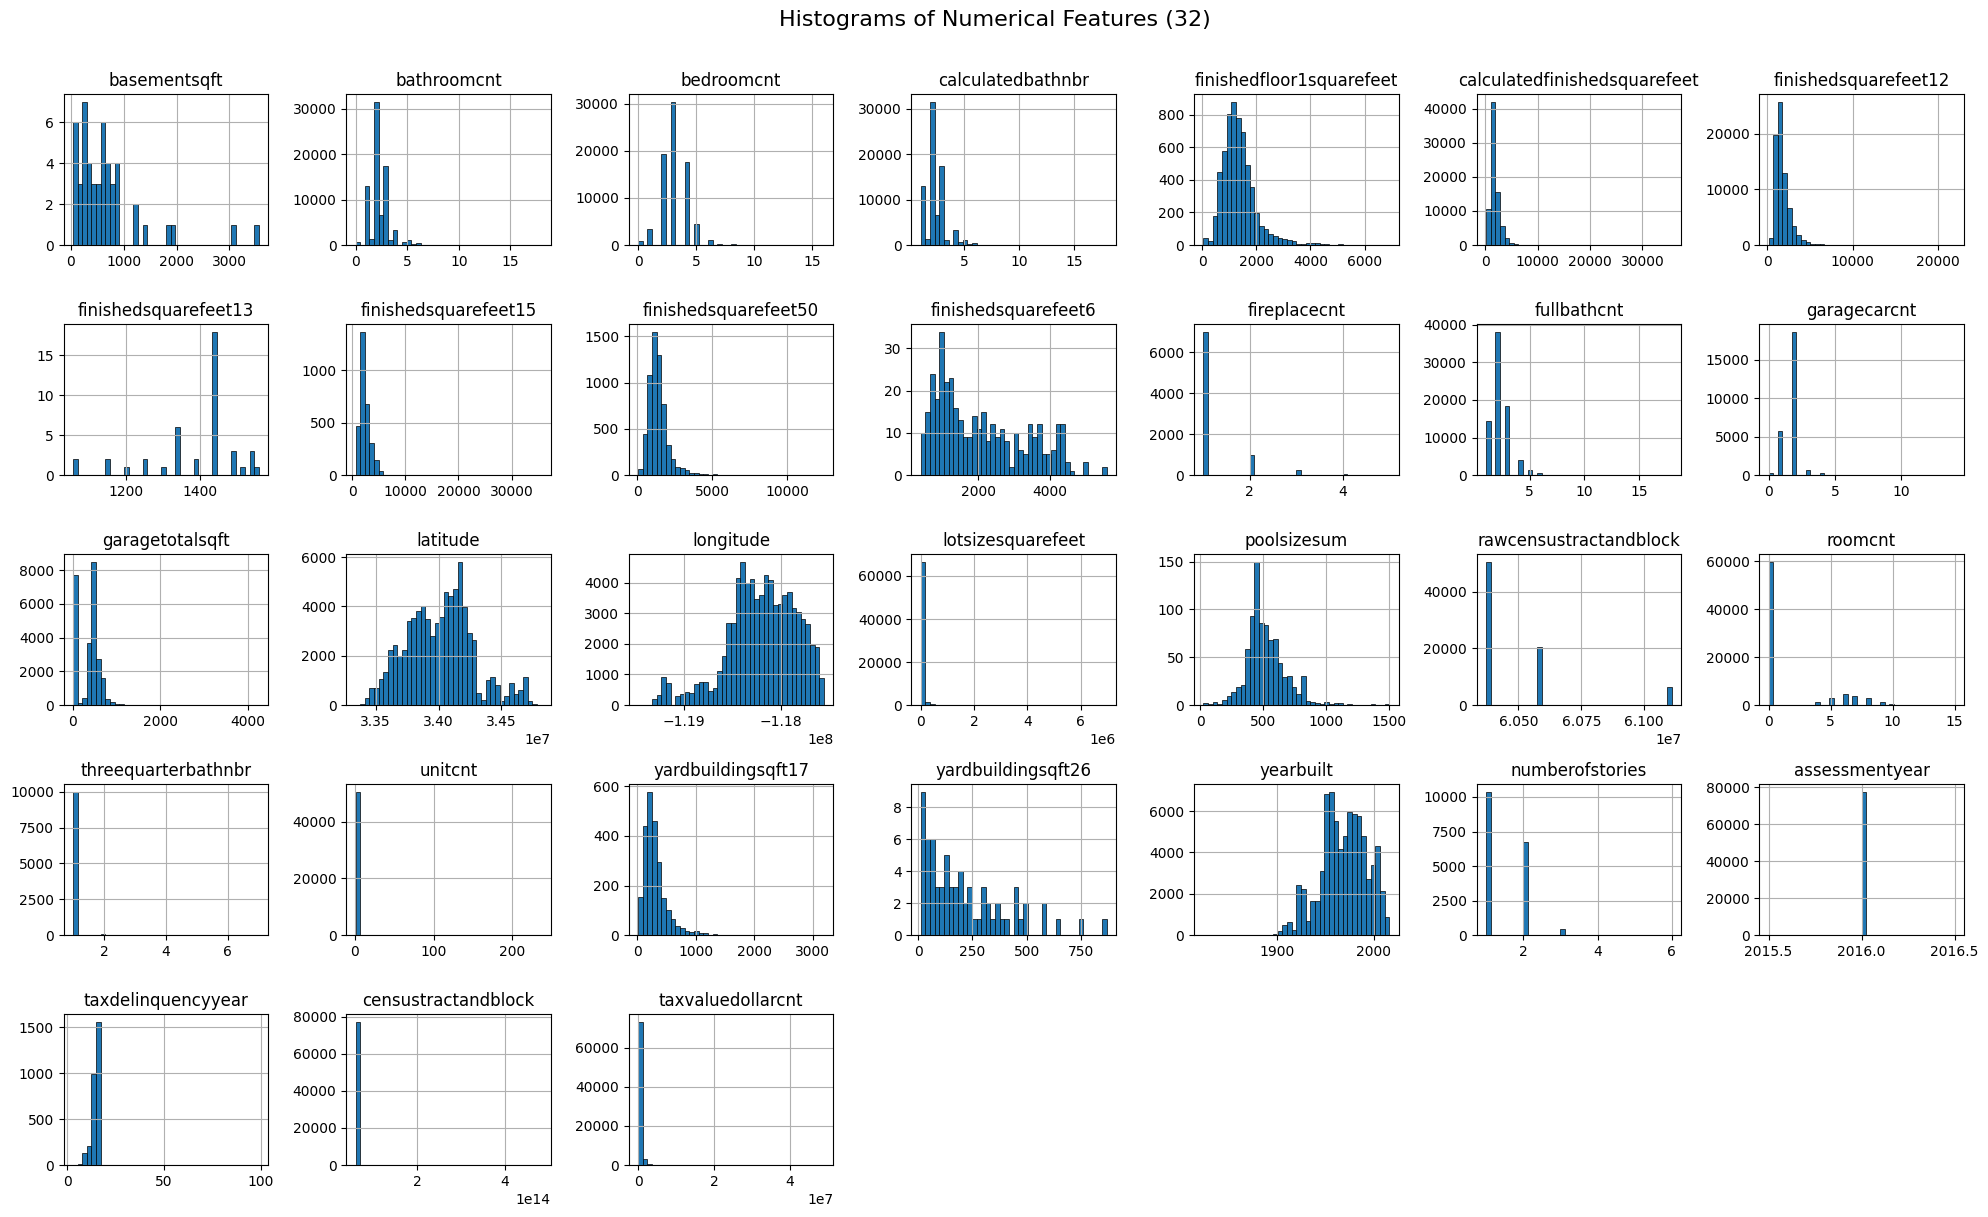

In [12]:
# Numerical histograms:

numerical =  ['basementsqft', 'bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolsizesum', 'rawcensustractandblock', 'roomcnt', 'threequarterbathnbr', 'unitcnt', 'yardbuildingsqft17', 'yardbuildingsqft26', 'yearbuilt', 'numberofstories', 'assessmentyear', 'taxdelinquencyyear', 'censustractandblock', 'taxvaluedollarcnt']

fig = df[numerical].hist(figsize=(20,12), layout=(-1, 7), bins=40, edgecolor='black', linewidth=0.5)
plt.suptitle("Histograms of Numerical Features (32)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

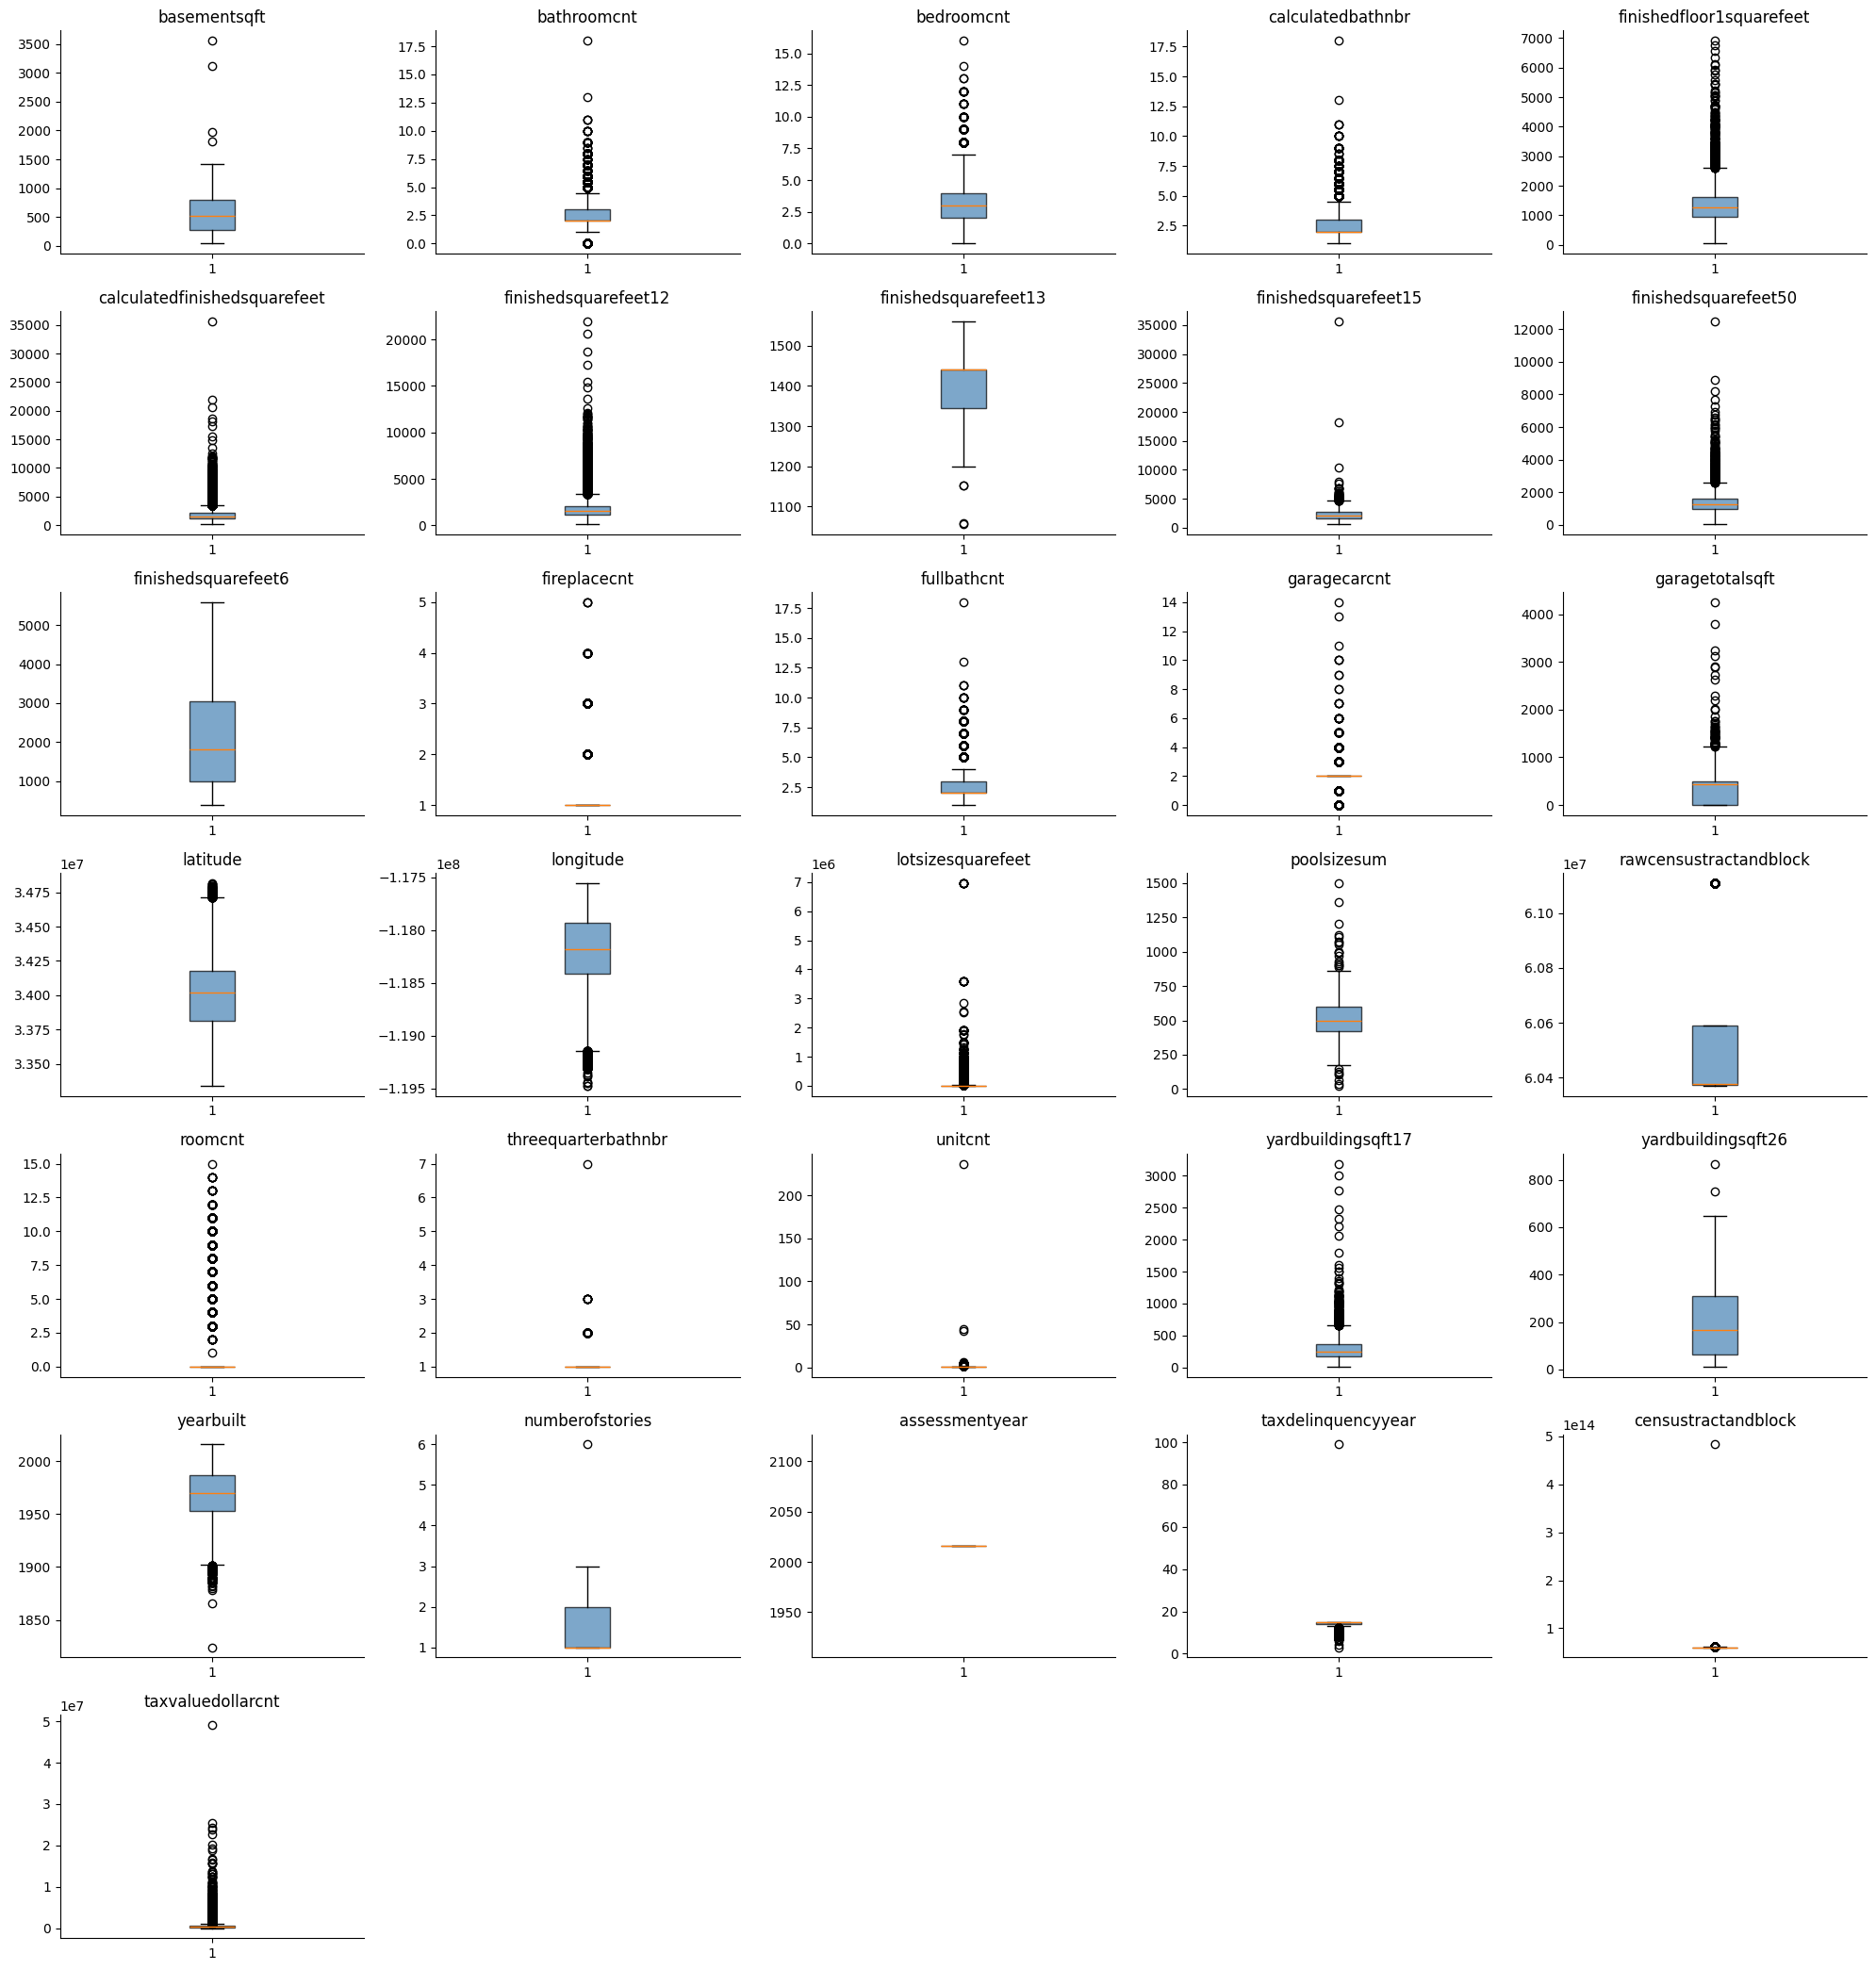

In [13]:
# Numerical boxplots: 
n = len(numerical)
cols = 5
rows = -(-n // cols)  # ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()

for i, col in enumerate(numerical):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()

- **Target** (**taxvaluedollarcnt**): right skewed with many outliers, which should be removed in during data cleanup. The bulk of values cluster below $1M, but the tail extends to ~$49M.
- **finishedsquarefeet** variants have different skews and outliers. Once cleaned or combined, outliers should be reexamined. calculatedfinishedsquarefeet and finishedsquarefeet12 look nearly identical, reinforcing the redundancy finding from data quality analysis.
- **finishedsquarefeet13** and **yearbuilt** are the only left-skewed numerical columns (longitude is left-skewed but reflects geography, not a meaningful distribution pattern).
- **decktypeid**: std = 0.0, all non-null values are 66 — a constant, confirmed in the zero-variance analysis from data quality analysis.
- **yardbuildingsqft** has multiple columns, both right skewed with the vast majority of values being very small.
- **assessmentyear** has only 1 value (2016), can be dropped — zero variance, no predictive value.
- **roomcnt**: the 75th percentile is 0, meaning most values are zero. This is suspicious for "total room count" and may indicate the field was not reliably populated or uses a non-obvious definition.
- **garagetotalsqft** shows a bimodal distribution — a peak at 0 (no garage) and a second peak around 400–500 sqft — suggesting it may be useful to convert this into a binary has_garage feature plus a garage_size feature.
- **bathroomcnt** and **bedroomcnt**: max values of 18 and 16 respectively are likely outliers or multi-unit properties that should be investigated during cleaning.

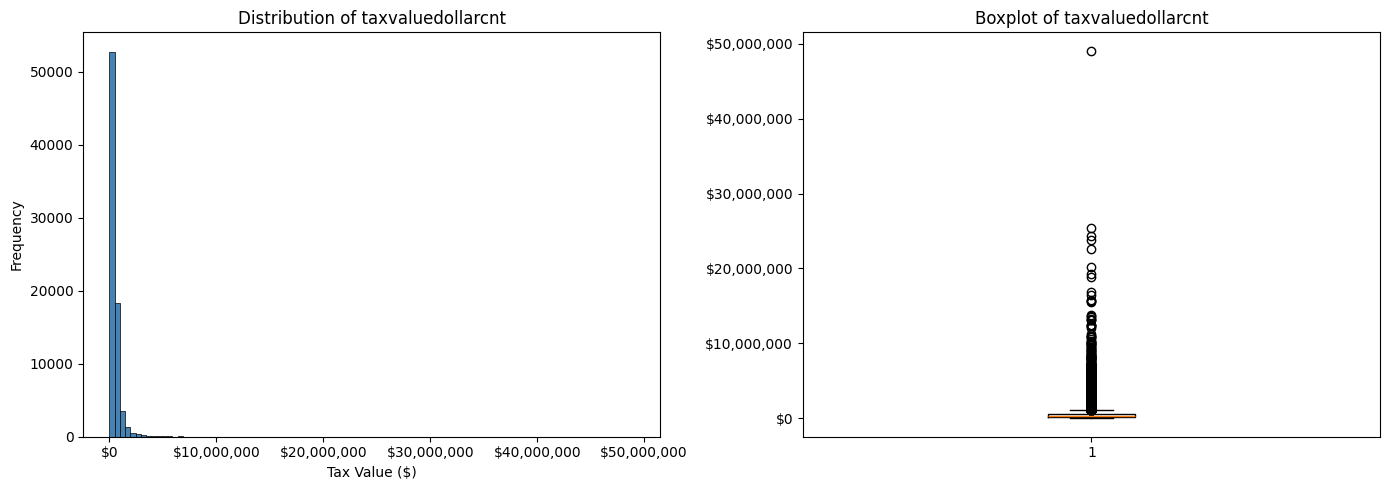

count    7.757800e+04
mean     4.901506e+05
std      6.537979e+05
min      1.000000e+03
25%      2.068985e+05
50%      3.588785e+05
75%      5.690000e+05
max      4.906124e+07
Name: taxvaluedollarcnt, dtype: float64


In [14]:
# Target deep dive:

target = "taxvaluedollarcnt"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram:
axes[0].hist(df[target].dropna(), bins=100, edgecolor='black', linewidth=0.5, color='steelblue')
axes[0].set_title(f"Distribution of {target}")
axes[0].set_xlabel("Tax Value ($)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

# boxplot:
axes[1].boxplot(df[target].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {target}")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.tight_layout()
plt.show()

print(df[target].describe())

1.46% are outliers, excluded from this histogram


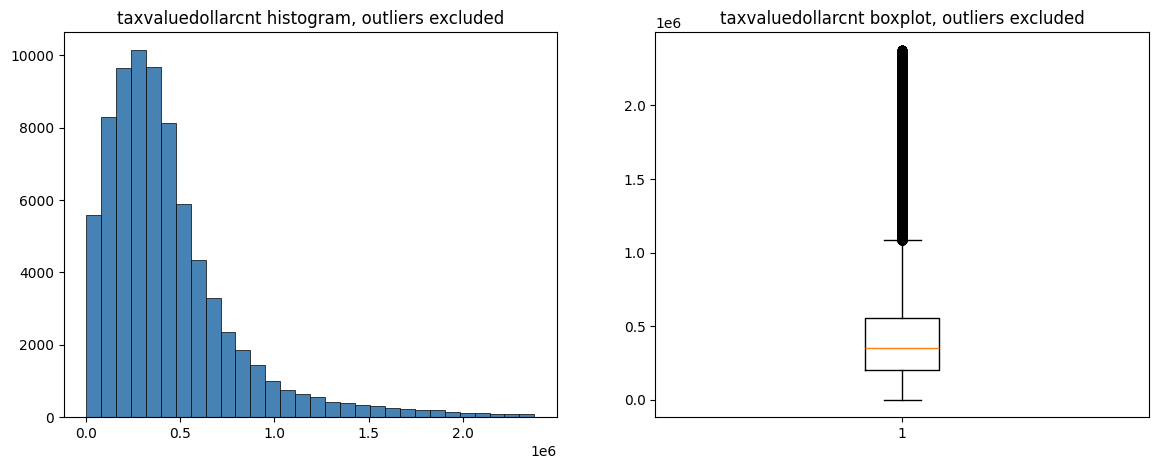

In [15]:
# Target deep dive, outliers removed:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# calculate outlier cutoff, defined by Q3 + x*IQR:
IQR = df[target].quantile(0.75) - df[target].quantile(0.25)
uppercutoff = df[target].quantile(0.75) + 5*IQR
lowercutoff = df[target].quantile(0.25) - 5*IQR

# create mask to exclude left and right-side outliers:
mask = (df[target] > lowercutoff) & (df[target] < uppercutoff)
no_outliers = df[mask]

# calculate % outliers:
target_outliers = abs(no_outliers.shape[0] / df[target].shape[0] - 1)*100
print(f"{target_outliers:.2f}% are outliers, excluded from this histogram")

# plot histogram:
axes[0].hist(no_outliers[target].dropna(), bins=30, edgecolor='black', linewidth=0.5, color='steelblue')
axes[0].set_title(f'{target} histogram, outliers excluded')
# show distance from mean on x-axis

# plot boxplot:
axes[1].boxplot(no_outliers[target].dropna(), vert=True)
axes[1].set_title(f'{target} boxplot, outliers excluded')

None


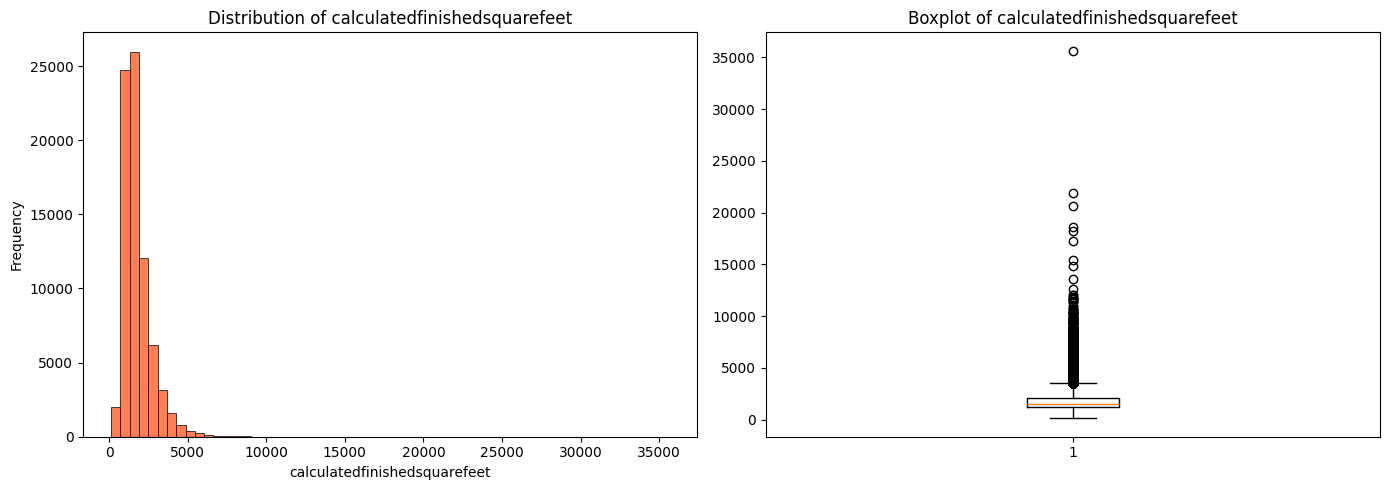

count    77378.000000
mean      1784.935421
std        954.250373
min        128.000000
25%       1182.000000
50%       1542.000000
75%       2112.000000
max      35640.000000
Name: calculatedfinishedsquarefeet, dtype: float64


In [16]:
# Feature 1 deep dive:

feature_1 = "calculatedfinishedsquarefeet"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram:
axes[0].hist(df[feature_1].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='coral')
axes[0].set_title(f"Distribution of {feature_1}")
axes[0].set_xlabel(feature_1)
axes[0].set_ylabel("Frequency")

# boxplot:
axes[1].boxplot(df[feature_1].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_1}")

plt.tight_layout()
plt.show()

print(df[feature_1].describe())

0.47% are outliers, excluded from this histogram


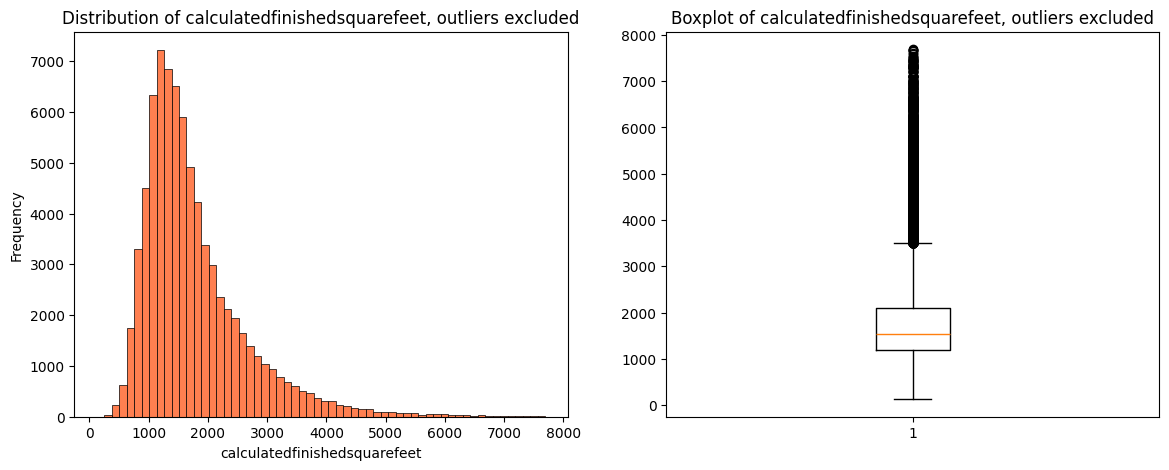

In [17]:
# Feature 1 deep dive, outliers removed:

# calculate outlier cutoff, defined by Q3 + 1.5IQR:
IQR = df[feature_1].quantile(0.75) - df[feature_1].quantile(0.25)
uppercutoff = df[feature_1].quantile(0.75) + 6*IQR
lowercutoff = df[feature_1].quantile(0.25) - 6*IQR

# create mask to exclude left and right-side outliers:
mask = (df[feature_1] > lowercutoff) & (df[feature_1] < uppercutoff)
no_outliers = df[mask]

# calculate % outliers:
feature_1_outliers = abs(no_outliers.shape[0] / df[feature_1].shape[0] - 1)*100
print(f"{feature_1_outliers:.2f}% are outliers, excluded from this histogram")

# plot histogram:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(no_outliers[feature_1].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='coral')
axes[0].set_title(f"Distribution of {feature_1}, outliers excluded")
axes[0].set_xlabel(feature_1)
axes[0].set_ylabel("Frequency")

# plot boxplot
axes[1].boxplot(no_outliers[feature_1].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_1}, outliers excluded")

plt.show()

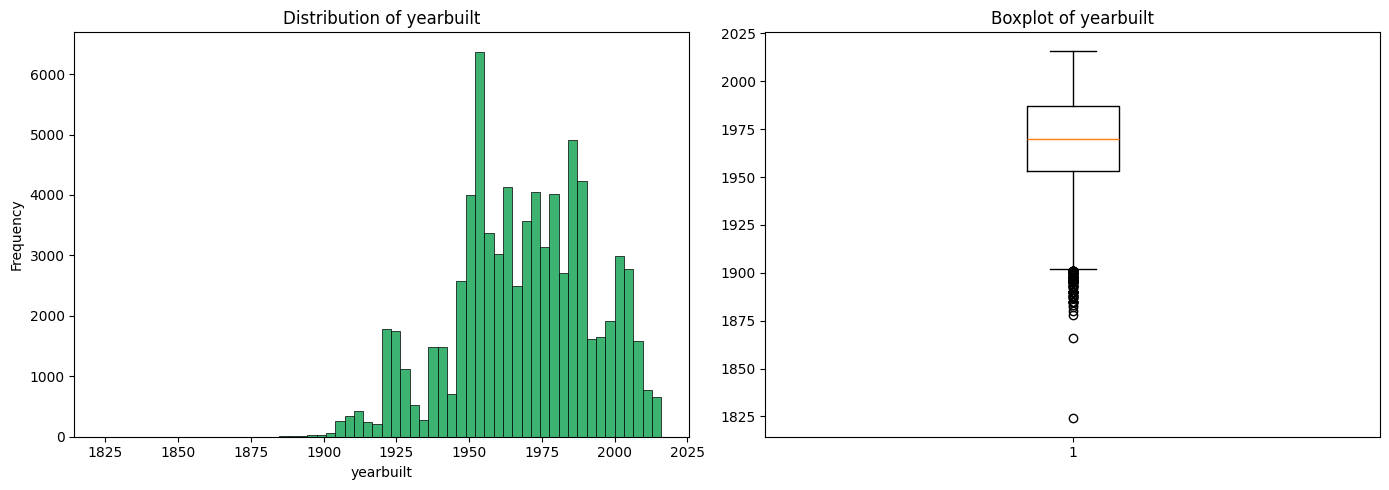

count    77309.000000
mean      1968.611507
std         23.793171
min       1824.000000
25%       1953.000000
50%       1970.000000
75%       1987.000000
max       2016.000000
Name: yearbuilt, dtype: float64


In [18]:
# Feature 2 deep dive:

feature_2 = "yearbuilt"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram:
axes[0].hist(df[feature_2].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='mediumseagreen')
axes[0].set_title(f"Distribution of {feature_2}")
axes[0].set_xlabel(feature_2)
axes[0].set_ylabel("Frequency")

# boxplot:
axes[1].boxplot(df[feature_2].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_2}")

plt.tight_layout()
plt.show()

print(df[feature_2].describe())

0.39% are outliers, excluded from this histogram


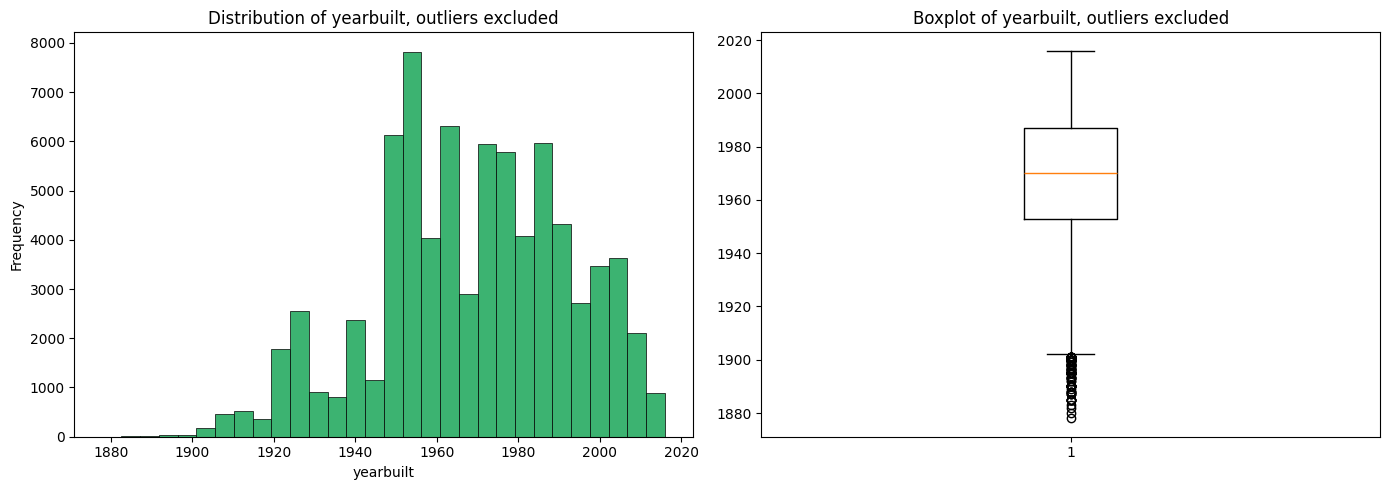

count    77309.000000
mean      1968.611507
std         23.793171
min       1824.000000
25%       1953.000000
50%       1970.000000
75%       1987.000000
max       2016.000000
Name: yearbuilt, dtype: float64


In [19]:
# Feature 2 deep dive, outliers removed:

# calculate outlier cutoff, defined by Q3 + 1.5IQR:
IQR = df[feature_2].quantile(0.75) - df[feature_2].quantile(0.25)
uppercutoff = df[feature_2].quantile(0.75) + 2.5*IQR
lowercutoff = df[feature_2].quantile(0.25) - 2.5*IQR

# create mask to exclude left and right-side outliers:
mask = (df[feature_2] > lowercutoff) & (df[feature_2] < uppercutoff)
no_outliers = df[mask]

# calculate % outliers:
feature_2_outliers = abs(no_outliers.shape[0] / df[feature_2].shape[0] - 1)*100
print(f"{feature_2_outliers:.2f}% are outliers, excluded from this histogram")

# plot:
feature_2 = "yearbuilt"  # <-- CHANGE IF DESIRED

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(no_outliers[feature_2].dropna(), bins=30, edgecolor='black', linewidth=0.5, color='mediumseagreen')
axes[0].set_title(f"Distribution of {feature_2}, outliers excluded")
axes[0].set_xlabel(feature_2)
axes[0].set_ylabel("Frequency")

axes[1].boxplot(no_outliers[feature_2].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_2}, outliers excluded")

plt.tight_layout()
plt.show()

print(df[feature_2].describe())

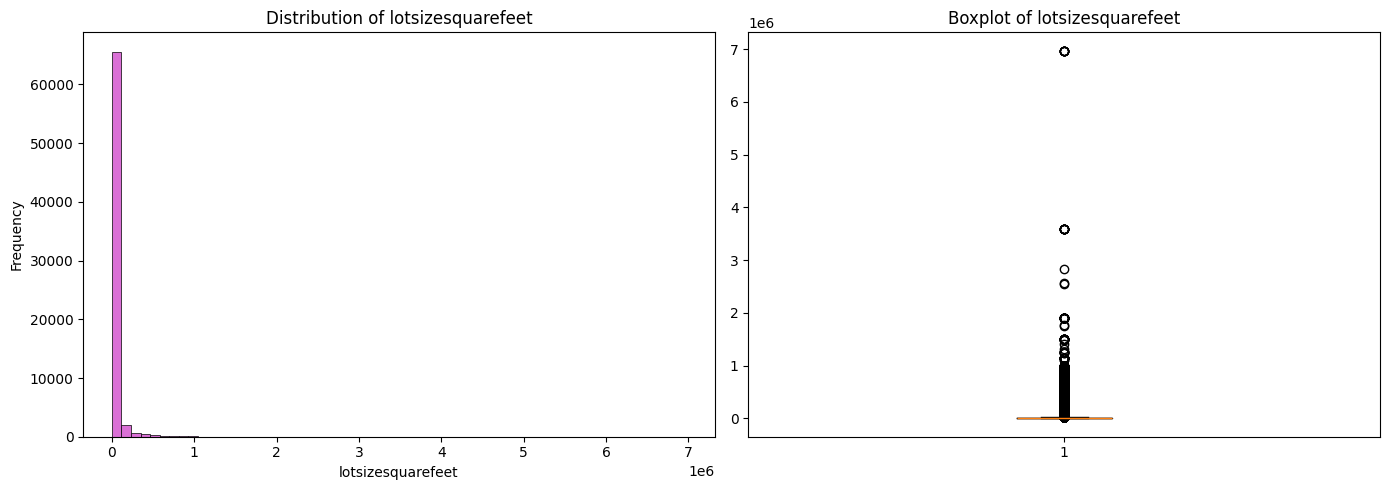

count    6.932100e+04
mean     2.997344e+04
std      1.233050e+05
min      2.360000e+02
25%      5.700000e+03
50%      7.206000e+03
75%      1.183700e+04
max      6.971010e+06
Name: lotsizesquarefeet, dtype: float64


In [20]:
# Feature 3 deep dive:

feature_3 = "lotsizesquarefeet"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram:
axes[0].hist(df[feature_3].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='orchid')
axes[0].set_title(f"Distribution of {feature_3}")
axes[0].set_xlabel(feature_3)
axes[0].set_ylabel("Frequency")

# boxplot:
axes[1].boxplot(df[feature_3].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_3}")

plt.tight_layout()
plt.show()

print(df[feature_3].describe())

12.72% are outliers, excluded from this histogram


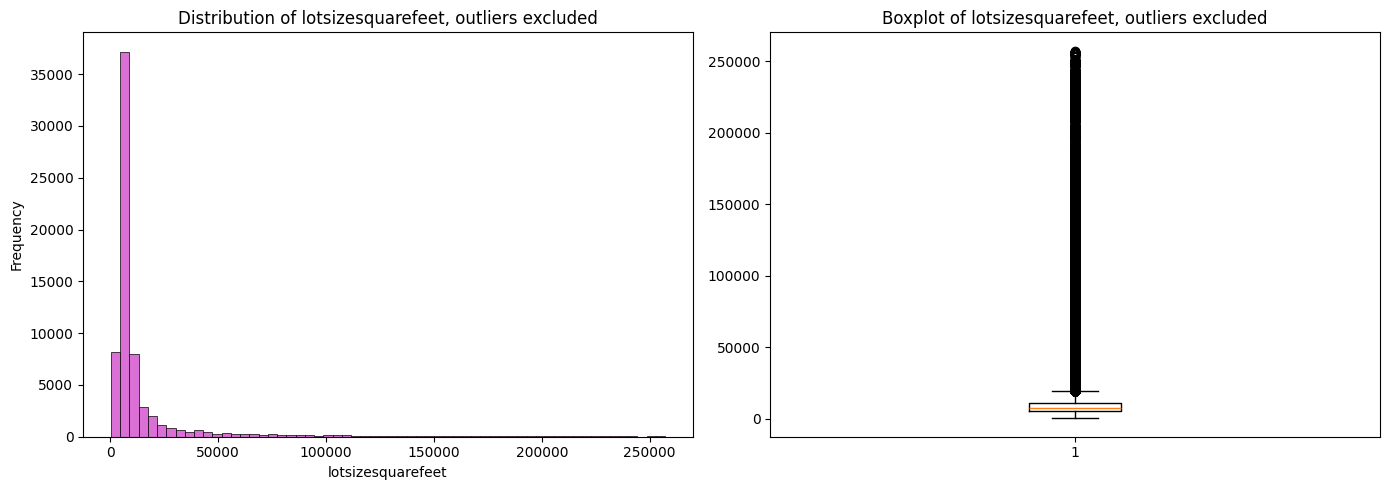

count    6.932100e+04
mean     2.997344e+04
std      1.233050e+05
min      2.360000e+02
25%      5.700000e+03
50%      7.206000e+03
75%      1.183700e+04
max      6.971010e+06
Name: lotsizesquarefeet, dtype: float64


In [21]:
# Feature 3 deep dive, outliers removed:

# calculate outlier cutoff, defined by Q3 + 1.5IQR:
IQR = df[feature_3].quantile(0.75) - df[feature_3].quantile(0.25)
uppercutoff = df[feature_3].quantile(0.75) + 40*IQR
lowercutoff = df[feature_3].quantile(0.25) - 40*IQR

# create mask to exclude left and right-side outliers:
mask = (df[feature_3] > lowercutoff) & (df[feature_3] < uppercutoff)
no_outliers = df[mask]

# calculate % outliers:
feature_3_outliers = abs(no_outliers.shape[0] / df[feature_3].shape[0] - 1)*100
print(f"{feature_3_outliers:.2f}% are outliers, excluded from this histogram")

# plot:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(no_outliers[feature_3].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='orchid')
axes[0].set_title(f"Distribution of {feature_3}, outliers excluded")
axes[0].set_xlabel(feature_3)
axes[0].set_ylabel("Frequency")

axes[1].boxplot(no_outliers[feature_3])
axes[1].set_title(f"Boxplot of {feature_3}, outliers excluded")

plt.tight_layout()
plt.show()

print(df[feature_3].describe())

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


The target column **taxvaluedollarcnt** was chosen to be examined because this is the target to predict, and the most important part of the model. It has a unimodal, exponential distribution, heavily right-skewed both with and without removing outliers. Some values are odd and considered to be outliers, such as a max value of $49,061,240 without near neighbors. The first feature is **calculatedfinishedsquarefeet**. Contextually, finished square feet should be correlated to sale price and the target variable, tax value. It is extremely right-skewed. Removing outliers shows the remaining distribution is unimodal with an exponential distribution, indicating it may be useful to transform exponentially or logarithmically. It has a peak at ~1200 and maintains the right skew. The second feature is **yearbuilt**. Contextually, age of house is also typically related to sale price and therefore tax value. This is one of the only left skewed features. With outliers removed, the remaining distribution shows a bimodal shape, with peaks around 1920 and 1955. It maintains the left skew. If this feature is important for predicting the target, the bimodal distribution may indicate that an appropriate model will be one that uses clustering or mutliple dimensions, rather than a simple linear regression. The third feature is **lotsizesquarefeet**. Similar to calculated finished square feet, overall lot size should be correlated to sale price and tax value in context. Again, this is extremely right skewed. It has a peak ~10,000. With outliers removed, the distribution is unimodal with an exponential distribution, indicating it may be useful to transform exponentially or logarithmically. It maintains the right skew.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [22]:
def drop_useless_features(dataframe: pd.DataFrame, columns_to_drop: list) -> pd.DataFrame:
    """Drop columns that are not useful for the regression task."""
    existing = [c for c in columns_to_drop if c in dataframe.columns]
    return dataframe.drop(columns=existing)

# TODO: Add/remove columns based on your analysis
useless_features = [
# CATEGORICAL FEATURES:
    "parcelid",                     # reference ID, not category
# NUMERICAL FEATURES:
    "assessmentyear",               # all assessed in 2016 except 36 nulls
]

df_dropped_features = drop_useless_features(df, useless_features)
print(f"Shape after dropping useless features: {df_dropped_features.shape}")
print(f"Dropped: {set(df.columns) - set(df_dropped_features.columns)}")

Shape after dropping useless features: (77613, 53)
Dropped: {'parcelid', 'assessmentyear'}


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


Only 2 features were dropped at this point. **parcelid** was dropped because it's a reference ID only, not categorical or meaningful. **assessmentyear** has every known value = 2016, so this does not add any information.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [23]:
# Remove:

null_cols_to_drop = [
# from nulls:
    "buildingclasstypeid",          # 99% null, no way to confidently impute
    "architecturalstyletypeid",     # 99% null, no way to confidently impute
    "typeconstructiontypeid",       # 99% null, no way to confidently impute
    "decktypeid",                   # 99% null, no way to confidently impute
    "taxdelinquencyyear",           # 96% null, similar to flag
    "airconditioningtypeid",        # 67% null, no way to confidently impute
    "hashottuborspa",               # 98% null and similar column exists
    "heatingorsystemtypeid",        # 35% null and 11 categories
    "propertyzoningdesc",           # 35% null and 2k categories
    "buildingqualitytypeid",        # 35% null and categorical
    "regionidcity",                 # can we impute with zip or drop
    "regionidcounty",               # redundant with fips
    "regionidneighborhood"          # can we impute with zip or drop
]
collinear_cols_to_drop = [
# from collinearity:
    "bathroomcnt",                  # feeds into calculatedbathnbr
    "threequarterbathnbr",          # feeds into calculatedbathnbr
    "fullbathcnt",                  # feeds into calculatedbathnbr
    "finishedsquarefeet6",          # correlation with calculatedfinishedsquarefeet = 1, nulls
    "finishedsquarefeet12",         # correlation with calculatedfinishedsquarefeet = 1
    "finishedsquarefeet13",         # correlation with calculatedfinishedsquarefeet = 1, nulls
    "finishedsquarefeet15",         # correlation with calculatedfinishedsquarefeet = 1, nulls
    "pooltypeid7",                  # 1 or null, feeds into poolcnt, high nulls
    "pooltypeid2",                  # 1 or null, feeds into poolcnt, high nulls
    "pooltypeid10",                 # 1 or null, feeds into poolcnt, high nulls
    "poolsizesum",                  # 98% null, similar column exists
    "rawcensustractandblock",       # repeat of fip, which is known not important
    "censustractandblock"           # same base digits as rawcensustractandblock
]
cols_to_drop = null_cols_to_drop + collinear_cols_to_drop
print("null columns to drop: ", len(null_cols_to_drop))
print("collinear columns to drop: ", len(collinear_cols_to_drop))
print("number of columns to drop: ", len(cols_to_drop))
df_dropped_nulls = df_dropped_features.drop(columns=cols_to_drop).copy(deep=True)

null columns to drop:  13
collinear columns to drop:  13
number of columns to drop:  26


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



To start, any features with over 80% null values were in consideration to be dropped. Too many null features are not reliable to impute. However, features were evaluated for exceptions. 1 exception is for feature groups, which were evaluated together, such as pooltypeid10, pooltypeid7, pooltypeid2. 1 other exception is there are cases where boolean columns are left null instead of "0" such as "fireplaceflag" or "poolcnt." (For exceptions where null means none, these will have 0s imputed in part 3.D, with table df_imputed. Ultimately, 13 columns were dropped due to nulls: ["buildingclasstypeid", "architecturalstyletypeid", "typeconstructiontypeid", "decktypeid", "taxdelinquencyyear", "airconditioningtypeid", "hashottuborspa", "heatingorsystemtypeid", "propertyzoningdesc", "buildingqualitytypeid", "regionidcity", "regionidcounty", "regionidneighborhood"].

Then, features were examined for collinearity. Multiple correlated columns would not add new information and can be detrimental to training a model. These features often had a mix of high collinearity or contextual similarity to another column, plus many null data points. Ultimately, 13 columns were dropped after examining for collinearity and nulls: ["bathroomcnt", "threequarterbathnbr", "fullbathcnt", "finishedsquarefeet6", "finishedsquarefeet12", "finishedsquarefeet13", "finishedsquarefeet15", "pooltypeid7", "pooltypeid2", "pooltypeid10",  "poolsizesum", "rawcensustractandblock", "censustractandblock"].


### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [24]:
TARGET = "taxvaluedollarcnt"

# create function to remove samples with null target:
def drop_null_target(dataframe: pd.DataFrame, target_col: str) -> pd.DataFrame:
    before = len(dataframe)
    result = dataframe.dropna(subset=[target_col])
    print(f"Dropped {before - len(result)} rows with null target")
    return result

# create function to remove rows with high nulls:
def drop_high_null_rows(dataframe: pd.DataFrame, threshold_pct: float = 50.0) -> pd.DataFrame:
    max_nulls = int(len(dataframe.columns) * (threshold_pct / 100))
    before = len(dataframe)
    result = dataframe.dropna(thresh=len(dataframe.columns) - max_nulls)
    print(f"Dropped {before - len(result)} rows with >{threshold_pct}% null columns")
    return result

# create function to remove outliers based on IQR:
def drop_target_outliers(dataframe: pd.DataFrame, target_col: str) -> pd.DataFrame:
    IQR = dataframe[target_col].quantile(0.75) - dataframe[target_col].quantile(0.25)
    uppercutoff = dataframe[target_col].quantile(0.75) + 5*IQR
    lowercutoff = dataframe[target_col].quantile(0.25) - 5*IQR
    mask = (dataframe[target_col] > lowercutoff) & (dataframe[target_col] < uppercutoff)
    no_outliers = dataframe[mask]
    before = len(dataframe)
    result = no_outliers
    print(f"Dropped {before - len(result)} target outlier rows")
    return result

df_clean = drop_null_target(df_dropped_nulls, TARGET)
df_clean = drop_high_null_rows(df_clean, threshold_pct=50.0)
df_dropped_samples = drop_target_outliers(df_clean, TARGET).copy(deep=True)
print(f"Shape after dropping samples: {df_dropped_samples.shape}")

Dropped 35 rows with null target
Dropped 2244 rows with >50.0% null columns
Dropped 1031 target outlier rows
Shape after dropping samples: (74303, 27)


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


There are 3 reasons why a sample was dropped. First, **null target**. These target values cannot be reasonably imputed to be useful to the model, since this is exactly what we're trying to learn how to predict, based on features. The sample rows with a null target were dropped. 35 rows were removed. Second, **high null row**. These samples had greater than half of the features being null. Even for features that belong in groups (and therefore once combined, samples will have fewer nulls for those grouped features), these grouped categories cannot account for close to 50% nulls. 2,244 rows were removed. Third, **target outliers**. Targets that are outliers, greater than the 75th percentile plus 5x the interquartile range, were removed from the cleaned data set. 1,031 rows were removed.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [25]:
# 4-part method to imputing nulls:

df_imputed = df_dropped_samples.copy(deep=True)

# Section A: Categorical columns
# 1. impute 3 categorical columns with Boolean values:
df_imputed["storytypeid"] = df_imputed["storytypeid"].map({7: 1}).fillna(0)
df_imputed["fireplaceflag"] = df_imputed["fireplaceflag"].map({True: 1}).fillna(0)
df_imputed["taxdelinquencyflag"] = df_imputed["taxdelinquencyflag"].map({"Y": 1}).fillna(0)
df_imputed["poolcnt"] = df_imputed["poolcnt"].fillna(0)

# 2. impute 1 categorical column with KNN K-Nearest Neighbors:
KNNimputer = KNNImputer(n_neighbors=5).fit(df_imputed[["regionidzip"]])     # default n_neighbors = 5
df_imputed["regionidzip"] = KNNimputer.transform(df_imputed[["regionidzip"]])

# 3. impute 2 categorical columns with mode:
def modeimputer(imputecol:str):
    imputer = SimpleImputer(strategy='most_frequent')
    # imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    imputer.fit(df_imputed[[imputecol]])
    df_imputed[imputecol] = imputer.transform(df_imputed[[imputecol]]).ravel()
    return df_imputed

modeimputer('propertylandusetypeid')
modeimputer('propertycountylandusecode')
modeimputer('fips')

# Section B: Numerical columns
# 4. impute numerical columns with median:
# create variable with only columns that still have nul
remainingnull = df_imputed.columns[df_imputed.isnull().any()].tolist()
medianimputer = SimpleImputer(missing_values=np.nan, strategy='median')
# pass in remainingnull columns only
df_imputed[remainingnull] = pd.DataFrame(medianimputer.fit_transform(df_imputed[remainingnull]), columns=remainingnull, index=df_imputed.index)

assert df_imputed.isnull().sum().sum() == 0, "There are still null values!"
print(f"Shape after imputation: {df_imputed.shape}")
print(f"Total remaining nulls: {df_imputed.isnull().sum().sum()}")


Shape after imputation: (74303, 27)
Total remaining nulls: 0


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


First, columns were split into categorical and numerical columns. For categorical columns, imputation method was manual if the column represented Boolean values, encoding the presence of something as "1" and absence as "0". The imputation method was KNN for regionidzip, which is categorical and ordinal. The imputation method was to use column mode for remaining categorical columns. Lastly, for numerical columns, imputation method was using column median which would not be affected by skew.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [33]:
# advanced encoding in future step feature engineering

def ordinal_encode(dataframe: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Ordinal-encode categorical columns."""
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    dataframe[columns] = encoder.fit_transform(dataframe[columns])
    return dataframe

df_encoded = df_imputed.copy(deep=True)
cat_cols = ['propertycountylandusecode']
df_encoded = ordinal_encode(df_encoded, cat_cols) 

print(f"Total remaining nulls: {df_encoded.isnull().sum().sum()}")


Total remaining nulls: 0


All remaining categorical features were already encoded during imputation in 3.D — boolean flags were converted to 0/1, and most categorical columns (propertylandusetypeid, fips, regionidzip) are already stored as numeric codes. The one exception was propertycountylandusecode, which contains alphanumeric codes (e.g., "010C") and was ordinal-encoded in this step.

## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

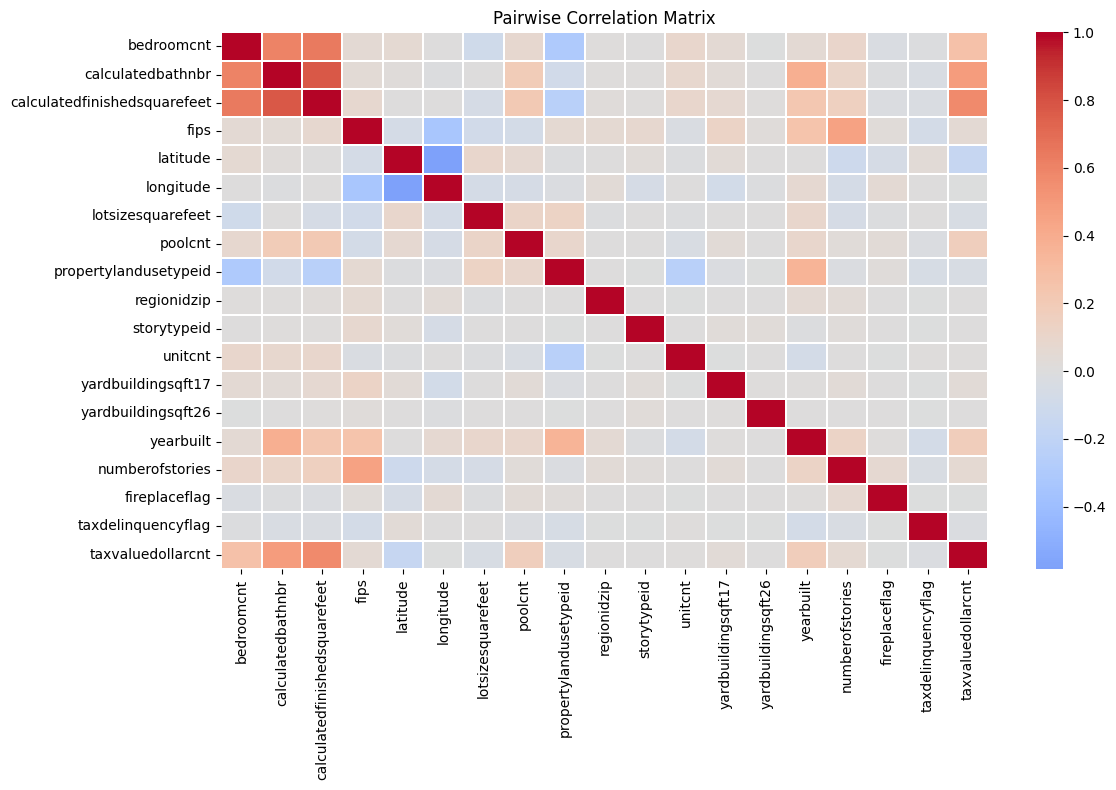

Correlation with target:
calculatedfinishedsquarefeet    0.571458
calculatedbathnbr               0.481226
bedroomcnt                      0.266016
yearbuilt                       0.173614
poolcnt                         0.167991
numberofstories                 0.058962
fips                            0.051285
yardbuildingsqft17              0.038797
unitcnt                         0.012727
storytypeid                     0.009314
yardbuildingsqft26              0.009010
regionidzip                     0.007436
fireplaceflag                  -0.007077
longitude                      -0.007383
taxdelinquencyflag             -0.019991
propertylandusetypeid          -0.039126
lotsizesquarefeet              -0.040009
latitude                       -0.157573
Name: taxvaluedollarcnt, dtype: float64


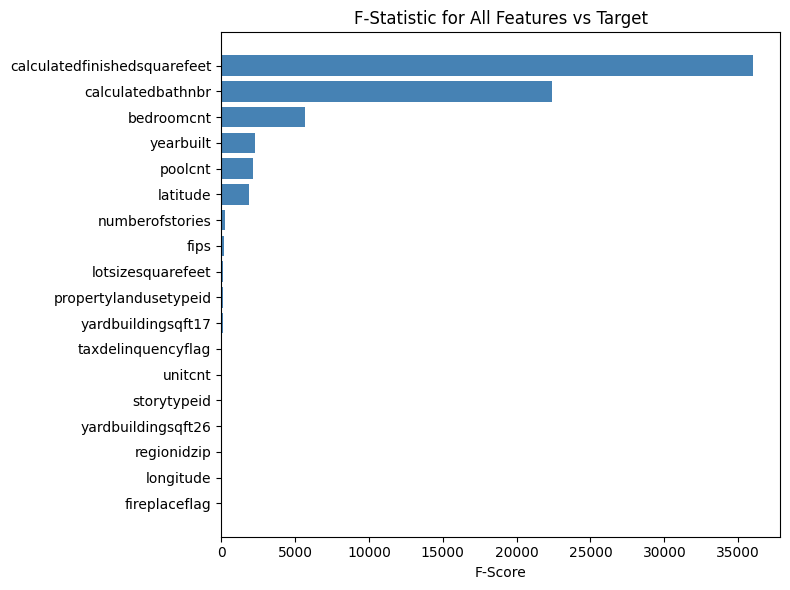

,feature,f_score,p_value
0,calculatedfinishedsquarefeet,36030.253143,0.000000e+00
1,calculatedbathnbr,22391.979432,0.000000e+00
2,bedroomcnt,5658.287215,0.000000e+00
3,yearbuilt,2309.159352,0.000000e+00
4,poolcnt,2157.748385,0.000000e+00
5,latitude,1891.805662,0.000000e+00
6,numberofstories,259.205972,3.208504e-58
7,fips,195.936268,1.833349e-44
8,lotsizesquarefeet,119.127338,1.030982e-27
9,propertylandusetypeid,113.916248,1.420990e-26


In [36]:
df_feat = df_encoded.drop(['basementsqft', 'finishedfloor1squarefeet', 'finishedsquarefeet50', 'fireplacecnt', 'garagecarcnt','garagetotalsqft','roomcnt','propertycountylandusecode'],axis=1) #we are having trouble with these features. For now we are dropping them. 

## Correlation Matrix

corr_matrix = df_feat.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

# Correlation with the target, sorted
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)

#F Stat

X = df_feat.drop(columns=[TARGET])
y = df_feat[TARGET]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({"feature": X.columns, "f_score": f_scores, "p_value": p_values})
f_df = f_df.sort_values("f_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.barh(f_df["feature"], f_df["f_score"], color="steelblue")
plt.xlabel("F-Score")
plt.title("F-Statistic for All Features vs Target")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

f_df.head(15)

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?

 Our correlations work as expected. The most correalted variable with the tax assessment is square feet of the house. This is highly correlated with bedroom count and bathroom count. It is interesting that lot size is not highly correlated with any variable. It is interesting that there is a slgihtly different correlation between latitude and longitude. It is possible that houses in a certain direction are more valuable, but it is surprising this had a difference with the raw data. When using a model, even simple regression, latitude and longitude are both higher priority variables. When allowing only 3 features, besides square feet, latitude and longitude are the next chosen variables. The methods do not have major disagreement except for the priority of latitude and longitude.



### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

## Pair 1: `calculatedfinishedsquarefeet` vs `taxvaluedollarcnt`

Rationale: sqft is universally the #1 driver of property value. This will show if the relationship is linear, nonlinear, or has clusters.

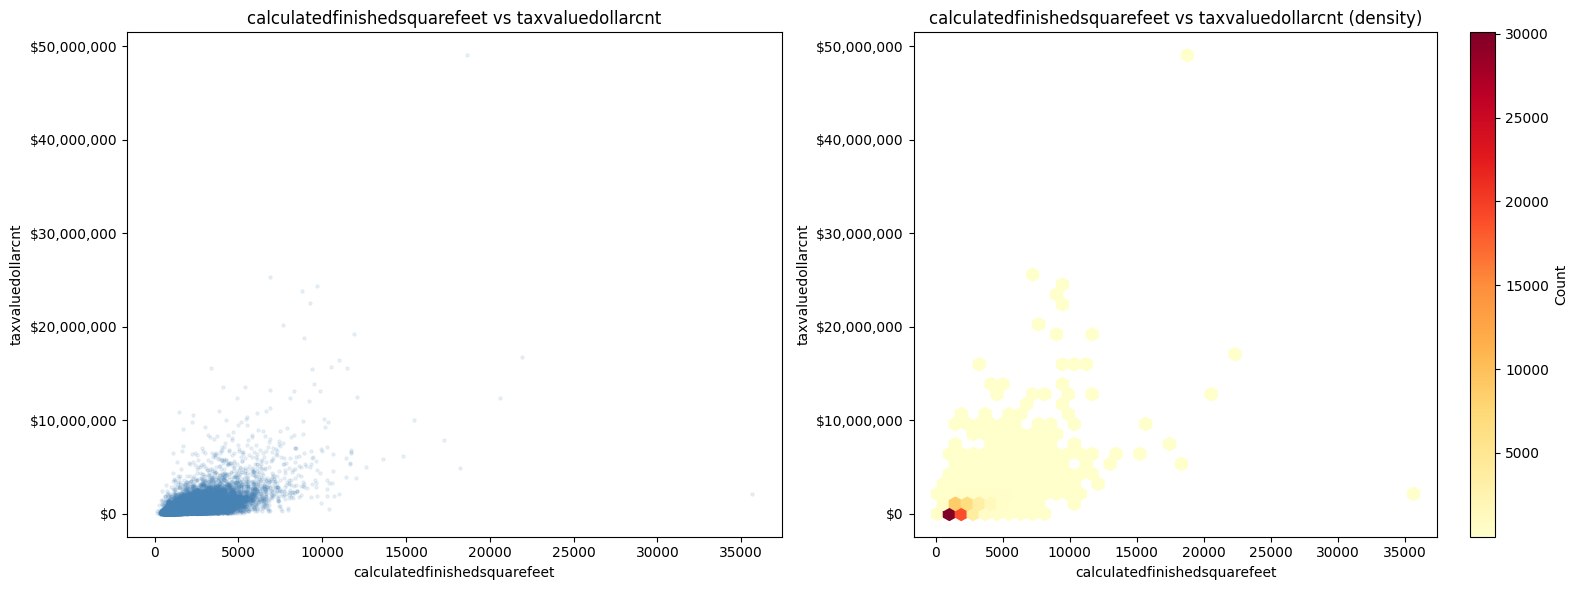

In [27]:
feat_x, feat_y = "calculatedfinishedsquarefeet", TARGET

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(df[feat_x], df[feat_y], alpha=0.1, s=5, color="steelblue")
axes[0].set_xlabel(feat_x)
axes[0].set_ylabel(feat_y)
axes[0].set_title(f"{feat_x} vs {feat_y}")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

# Density plot (hexbin) for a cleaner view
hb = axes[1].hexbin(df[feat_x], df[feat_y], gridsize=40, cmap="YlOrRd", mincnt=1)
axes[1].set_xlabel(feat_x)
axes[1].set_ylabel(feat_y)
axes[1].set_title(f"{feat_x} vs {feat_y} (density)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.colorbar(hb, ax=axes[1], label="Count")

plt.tight_layout()
plt.show()

### Observations — Pair 1

- **Direction**: Clear positive relationship — as square footage increases, tax value increases.
- **Shape**: The relationship is roughly linear for properties under ~3,000 sqft, but the scatter widens significantly above that. This suggests a log or polynomial transform on sqft might improve linearity.
- **Density**: The hexbin plot reveals the vast majority of properties cluster in a tight band between 1,000–2,500 sqft and $100K–$600K. This is the "typical home" zone — the model will learn this relationship most reliably.
- **Outliers**: A few properties with very large sqft (>5,000) show unpredictable tax values — these are likely luxury homes where finish quality, location, and amenities matter more than raw size.
- **Implication**: Square footage is a strong linear predictor for the bulk of data, but additional features are needed to explain variance in larger/luxury properties.

## Pair 2: `yearbuilt` vs `taxvaluedollarcnt`

Rationale: In EDA you found yearbuilt has a bimodal distribution. Plotting it against the target reveals whether newer homes are more valuable and whether the 1920s/1950s peaks show different value bands.

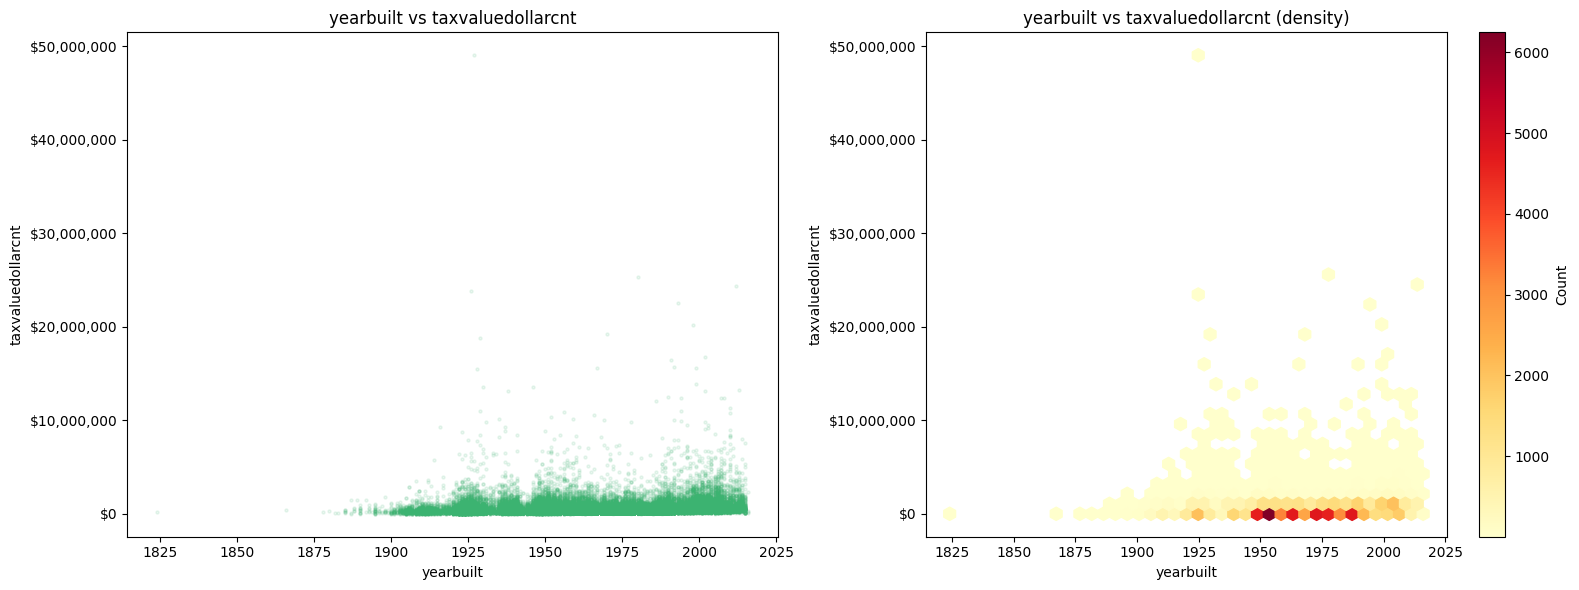

In [28]:
feat_x, feat_y = "yearbuilt", TARGET

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df[feat_x], df[feat_y], alpha=0.1, s=5, color="mediumseagreen")
axes[0].set_xlabel(feat_x)
axes[0].set_ylabel(feat_y)
axes[0].set_title(f"{feat_x} vs {feat_y}")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

hb = axes[1].hexbin(df[feat_x], df[feat_y], gridsize=40, cmap="YlOrRd", mincnt=1)
axes[1].set_xlabel(feat_x)
axes[1].set_ylabel(feat_y)
axes[1].set_title(f"{feat_x} vs {feat_y} (density)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.colorbar(hb, ax=axes[1], label="Count")

plt.tight_layout()
plt.show()

### Observations — Pair 2

- **Direction**: Generally positive — newer homes tend to have higher tax values, but the relationship is much weaker than sqft vs target.
- **Shape**: Not linear. There's a "fan" shape — older homes (pre-1960) have a narrow, lower range of values, while newer homes (post-1980) show a much wider spread. This heteroscedasticity (unequal variance) means yearbuilt alone is a poor predictor.
- **Density**: The hexbin confirms two high-density zones around 1950 and 1980, matching the bimodal distribution found in notebook 02. Properties built around 1955 cluster tightly around $200K–$400K.
- **Notable pattern**: Homes built after ~2000 show the highest tax values on average, but also the widest range — some new homes are assessed very low (possibly condos or small units).
- **Implication**: Year built is useful as a supporting feature but not as a standalone predictor. It may work better as an interaction term (e.g., yearbuilt × sqft) or after binning into age categories.

## Pair 3: `calculatedfinishedsquarefeet` vs `lotsizesquarefeet` (colored by target)

Rationale: This shows whether properties cluster into types (small house on big lot vs big house on small lot) and how that affects value. Using the target as color adds a 3rd dimension.

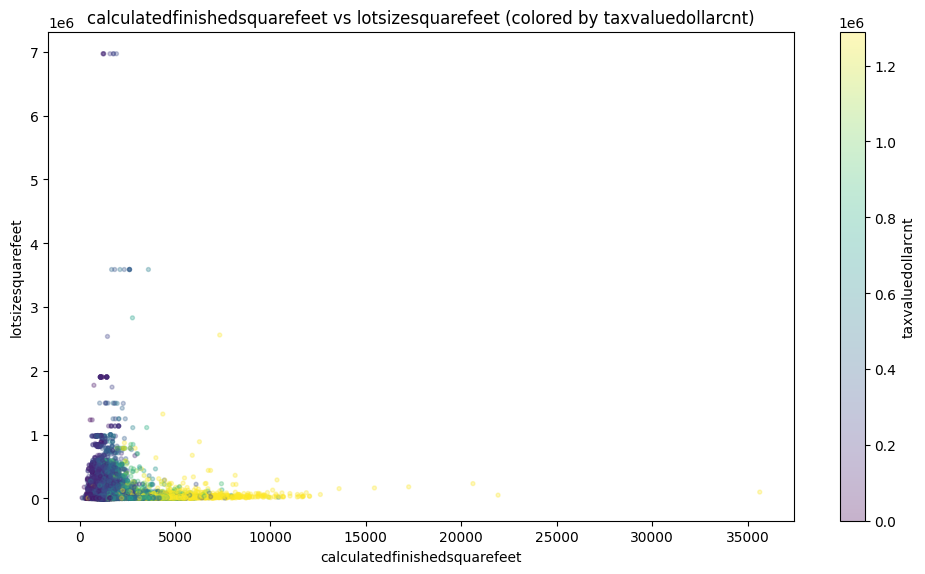

In [29]:
feat_x, feat_y = "calculatedfinishedsquarefeet", "lotsizesquarefeet"

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df[feat_x], df[feat_y],
    c=df[TARGET], cmap="viridis", alpha=0.3, s=8, norm=plt.Normalize(vmin=0, vmax=df[TARGET].quantile(0.95))
)
plt.colorbar(scatter, label=TARGET)
plt.xlabel(feat_x)
plt.ylabel(feat_y)
plt.title(f"{feat_x} vs {feat_y} (colored by {TARGET})")
plt.tight_layout()
plt.show()

### Observations — Pair 3

- **Cluster pattern**: Most properties are tightly packed in the bottom-left corner (small lot, small house). This tells us the dataset is dominated by standard residential properties.
- **Color gradient**: Within the main cluster, brighter colors (higher tax value) tend to appear toward the right side — meaning that finished square footage is a stronger driver of value than lot size. Two properties on the same size lot can have very different values if one has more finished space.
- **Lot size outliers**: There are a few properties with very large lots (>100,000 sqft) but relatively small finished areas — these could be rural or agricultural properties with low tax assessments (dark purple colors confirm this).
- **No strong lot size signal**: Moving upward (larger lot) does not consistently change the color from dark to bright, confirming that lot size alone is a weak predictor compared to finished square footage.
- **Implication**: A ratio feature like `calculatedfinishedsquarefeet / lotsizesquarefeet` (building-to-lot ratio) could capture the "intensity of development" and may be a useful engineered feature in notebook 06.

Overall, these bivariate analyses confirm that calculatedfinishedsquarefeet is the dominant predictor, while yearbuilt and lotsizesquarefeet play supporting roles. The nonlinear patterns and heteroscedasticity observed here suggest that log transforms (explored in notebook 06) and ensemble models (which handle nonlinearity naturally) may outperform simple linear regression.

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


Brief interpretations of observed patterns or trends:

**Pair 1 (sqft vs target):** There is a clear positive linear relationship between finished square footage and tax value — larger homes are assessed at higher values. However, the relationship becomes noisier above ~3,000 sqft, suggesting that for very large properties, other factors (location, quality) dominate. The density plot confirms that the vast majority of properties cluster in the 1,000–2,500 sqft range with values under $600K.

**Pair 2 (yearbuilt vs target):** Newer homes (post-1980) show a wider range of tax values and generally higher assessments, while older homes (pre-1950) cluster in a tighter, lower value band. This confirms that age is a factor, but the spread for recent construction is large — indicating that year alone is not sufficient for prediction.

**Pair 3 (sqft vs lot size, colored by target):** Most properties cluster in the bottom-left (small lot, small house) with moderate values. High-value properties (yellow/bright) tend to have larger finished square footage but not necessarily larger lots, suggesting that structure size matters more than land size for tax assessment in this market.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

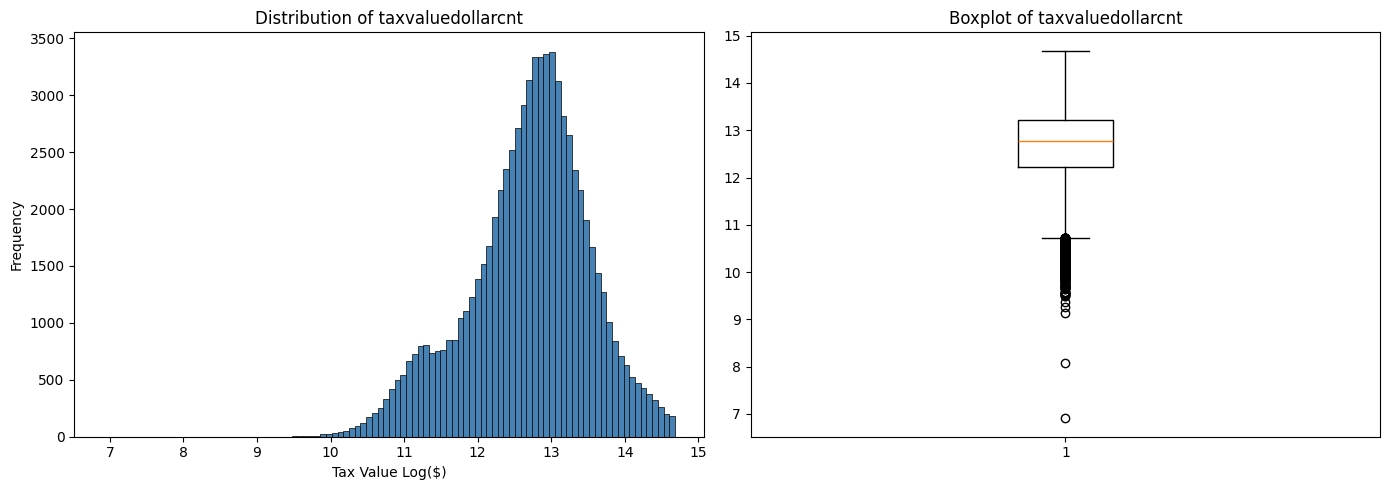

count    74303.000000
mean        12.685514
std          0.825112
min          6.907755
25%         12.223775
50%         12.774951
75%         13.226723
max         14.681412
Name: taxvaluedollarcnt, dtype: float64


In [41]:
#Feature 1: Log of Target. The taxvalue is heavily skeweded right, so we take the log. We then test to make sure that the models still work. 

df_log = df_feat.copy()
df_log[TARGET] = np.log(df[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_log[TARGET].dropna(), bins=100, edgecolor='black', linewidth=0.5, color='steelblue')
axes[0].set_title(f"Distribution of {TARGET}")
axes[0].set_xlabel("Tax Value Log($)")
axes[0].set_ylabel("Frequency")

# Boxplot
axes[1].boxplot(df_log[TARGET].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {TARGET}")

plt.tight_layout()
plt.show()

print(df_log[TARGET].describe())

#it looks like we can avoid any serious outlier removal by using the log transform, which is good because we don't want to lose data. 
# We can still consider capping extreme outliers if needed

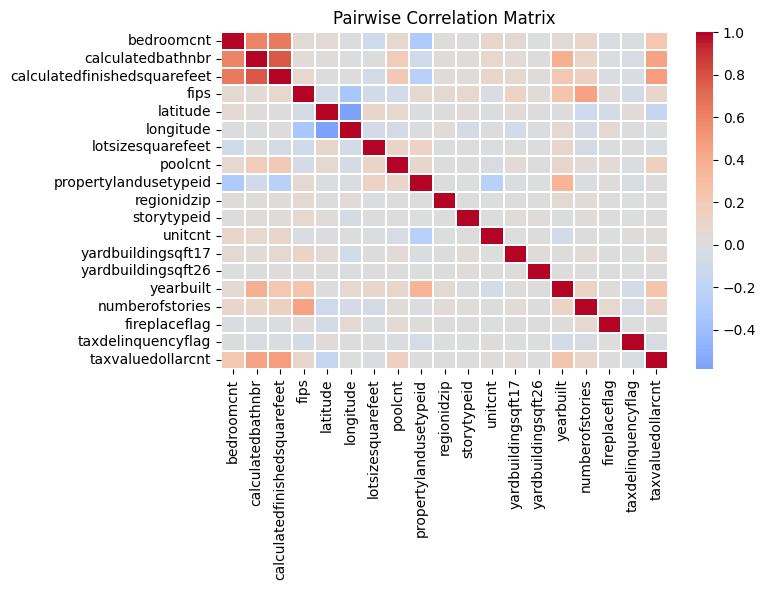

Correlation with target:
calculatedfinishedsquarefeet    0.478170
calculatedbathnbr               0.445740
yearbuilt                       0.251312
bedroomcnt                      0.232948
poolcnt                         0.157027
fips                            0.092497
numberofstories                 0.085007
yardbuildingsqft17              0.033278
unitcnt                         0.012476
propertylandusetypeid           0.007621
regionidzip                     0.007514
yardbuildingsqft26              0.007467
storytypeid                     0.006037
fireplaceflag                   0.000300
longitude                      -0.005972
lotsizesquarefeet              -0.027586
taxdelinquencyflag             -0.042484
latitude                       -0.157166
Name: taxvaluedollarcnt, dtype: float64


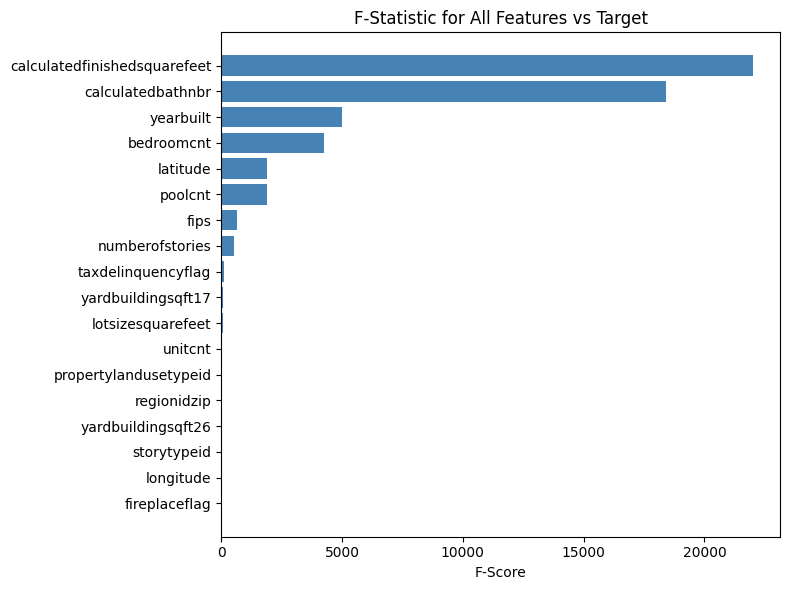

Forward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'yearbuilt']
Backward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'yearbuilt']
Common to both:  {'calculatedfinishedsquarefeet', 'yearbuilt', 'longitude', 'latitude', 'calculatedbathnbr', 'bedroomcnt'}
Only forward:    set()
Only backward:   set()


In [42]:
## Check Effect of Log(Target)

corr_matrix = df_log.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

# Correlation with the target, sorted
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)

#F Stat for Log(Target)

X = df_log.drop(columns=[TARGET])
y = df_log[TARGET]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({"feature": X.columns, "f_score": f_scores, "p_value": p_values})
f_df = f_df.sort_values("f_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.barh(f_df["feature"], f_df["f_score"], color="steelblue")
plt.xlabel("F-Score")
plt.title("F-Statistic for All Features vs Target")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

f_df.head(15)

#Feature Selection with Log(Target)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 6  # TODO: adjust

# Forward selection
sfs_forward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="forward", cv=3, scoring="neg_mean_squared_error"
)
sfs_forward.fit(X_scaled, y)
forward_features = X.columns[sfs_forward.get_support()].tolist()
print(f"Forward selection ({n_select}): {forward_features}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 6  # TODO: adjust

# Backward selection
sfs_backward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="backward", cv=3, scoring="r2"
)
sfs_backward.fit(X_scaled, y)
backward_features = X.columns[sfs_backward.get_support()].tolist()
print(f"Backward selection ({n_select}): {backward_features}")

# Compare the two methods
common = set(forward_features) & set(backward_features)
only_forward = set(forward_features) - set(backward_features)
only_backward = set(backward_features) - set(forward_features)

print(f"Common to both:  {common}")
print(f"Only forward:    {only_forward}")
print(f"Only backward:   {only_backward}")

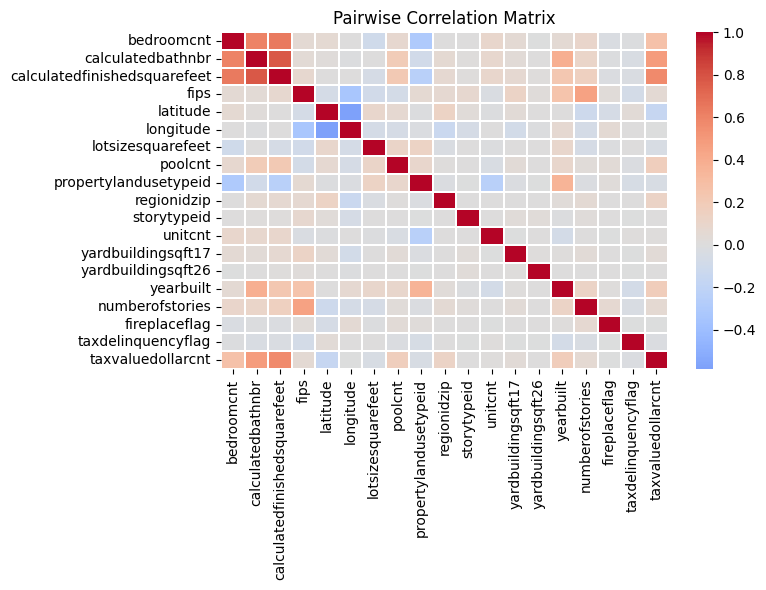

Correlation with target:
calculatedfinishedsquarefeet    0.571458
calculatedbathnbr               0.481226
bedroomcnt                      0.266016
yearbuilt                       0.173614
poolcnt                         0.167991
regionidzip                     0.115870
numberofstories                 0.058962
fips                            0.051285
yardbuildingsqft17              0.038797
unitcnt                         0.012727
storytypeid                     0.009314
yardbuildingsqft26              0.009010
fireplaceflag                  -0.007077
longitude                      -0.007383
taxdelinquencyflag             -0.019991
propertylandusetypeid          -0.039126
lotsizesquarefeet              -0.040009
latitude                       -0.157573
Name: taxvaluedollarcnt, dtype: float64


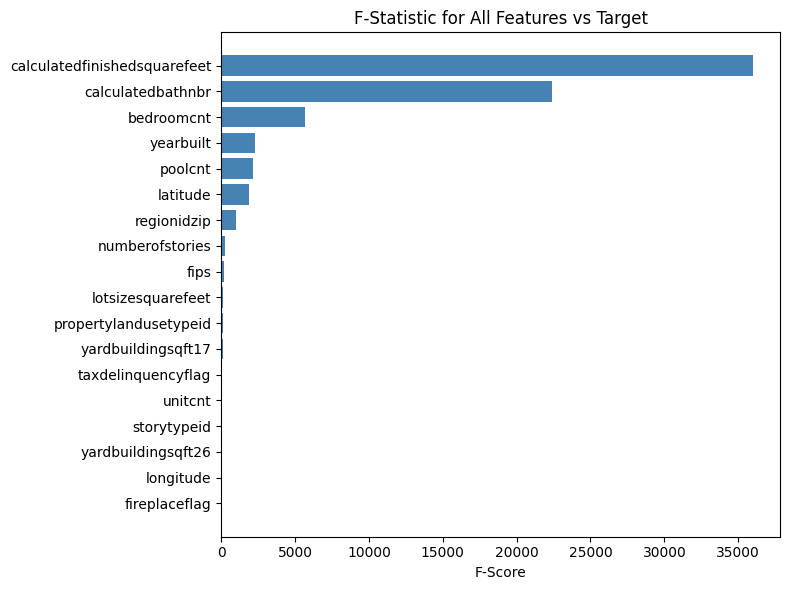

Forward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'regionidzip']
Backward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'regionidzip']
Common to both:  {'calculatedfinishedsquarefeet', 'longitude', 'regionidzip', 'latitude', 'calculatedbathnbr', 'bedroomcnt'}
Only forward:    set()
Only backward:   set()


In [49]:
## Feature Number 2: Encode zip codes based on mean tax value. 

df_zip = df_feat.copy()

# Encode regionidzip using KMeans:
# compute mean of related column per category:
cat_means = df_zip.groupby("regionidzip")["taxvaluedollarcnt"].mean()


# map means back and cluster into 10 groups:
df_zip["regionidzip"] = df_zip["regionidzip"].map(cat_means)
kmeans = KMeans(n_clusters=10, random_state=RANDOM_STATE)
df_zip["regionidzip"] = kmeans.fit_predict(df_zip[["regionidzip"]])



## Check Effect of Zip Encoding

corr_matrix = df_zip.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()




# Correlation with the target, sorted
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)




#F Stat 

X = df_zip.drop(columns=[TARGET])
y = df_zip[TARGET]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({"feature": X.columns, "f_score": f_scores, "p_value": p_values})
f_df = f_df.sort_values("f_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.barh(f_df["feature"], f_df["f_score"], color="steelblue")
plt.xlabel("F-Score")
plt.title("F-Statistic for All Features vs Target")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

f_df.head(15)

#Feature Selection with Zip Encoding

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 6  # TODO: adjust

# Forward selection
sfs_forward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="forward", cv=3, scoring="neg_mean_squared_error"
)
sfs_forward.fit(X_scaled, y)
forward_features = X.columns[sfs_forward.get_support()].tolist()
print(f"Forward selection ({n_select}): {forward_features}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 6  # TODO: adjust

# Backward selection
sfs_backward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="backward", cv=3, scoring="r2"
)
sfs_backward.fit(X_scaled, y)
backward_features = X.columns[sfs_backward.get_support()].tolist()
print(f"Backward selection ({n_select}): {backward_features}")

# Compare the two methods
common = set(forward_features) & set(backward_features)
only_forward = set(forward_features) - set(backward_features)
only_backward = set(backward_features) - set(forward_features)

print(f"Common to both:  {common}")
print(f"Only forward:    {only_forward}")
print(f"Only backward:   {only_backward}")

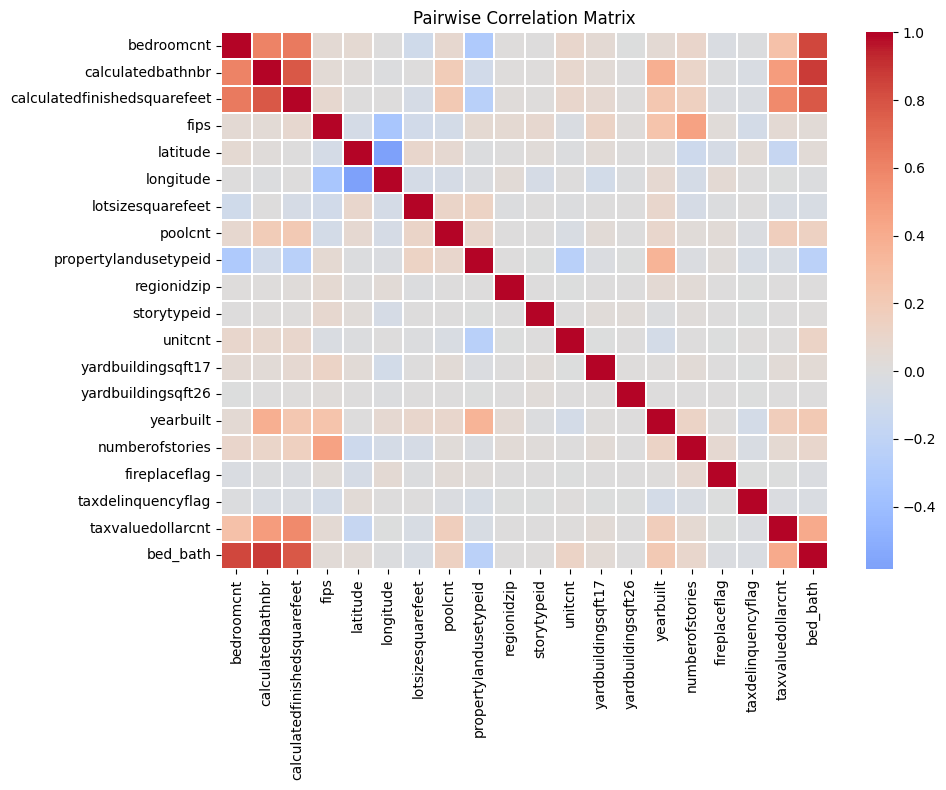

Correlation with target:
calculatedfinishedsquarefeet    0.571458
calculatedbathnbr               0.481226
bed_bath                        0.407074
bedroomcnt                      0.266016
yearbuilt                       0.173614
poolcnt                         0.167991
numberofstories                 0.058962
fips                            0.051285
yardbuildingsqft17              0.038797
unitcnt                         0.012727
storytypeid                     0.009314
yardbuildingsqft26              0.009010
regionidzip                     0.007436
fireplaceflag                  -0.007077
longitude                      -0.007383
taxdelinquencyflag             -0.019991
propertylandusetypeid          -0.039126
lotsizesquarefeet              -0.040009
latitude                       -0.157573
Name: taxvaluedollarcnt, dtype: float64


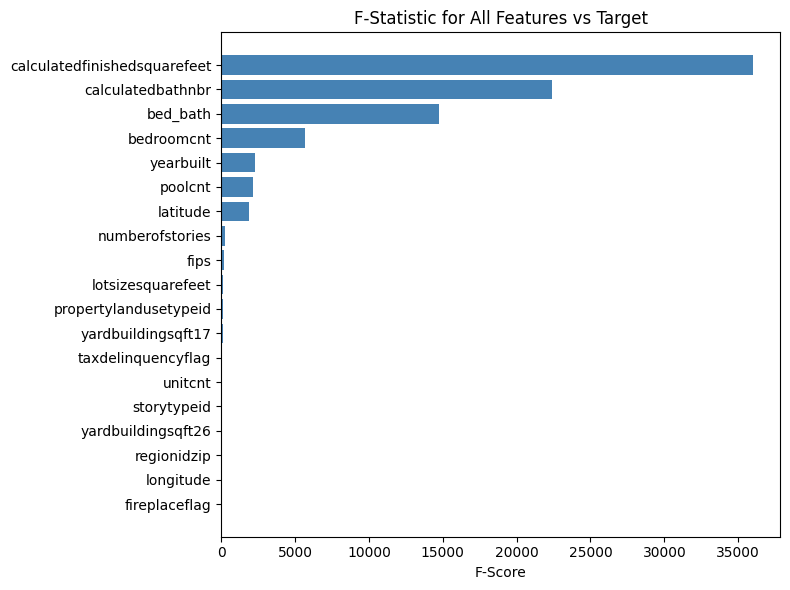

Forward selection (8): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fips', 'latitude', 'longitude', 'propertylandusetypeid', 'numberofstories']
Backward selection (8): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fips', 'latitude', 'longitude', 'propertylandusetypeid', 'numberofstories']
Common to both:  {'numberofstories', 'calculatedfinishedsquarefeet', 'fips', 'longitude', 'propertylandusetypeid', 'latitude', 'calculatedbathnbr', 'bedroomcnt'}
Only forward:    set()
Only backward:   set()


In [50]:
## Feature Number 3: Bed*Bath Interaction

df_bedbath = df_feat.copy()

df_bedbath['bed_bath']=df_bedbath['bedroomcnt'] * df_bedbath['calculatedbathnbr']

## Check Effect of Bed*Bath Interaction

corr_matrix = df_bedbath.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

# Correlation with the target, sorted
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)

#F Stat 

X = df_bedbath.drop(columns=[TARGET])
y = df_bedbath[TARGET]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({"feature": X.columns, "f_score": f_scores, "p_value": p_values})
f_df = f_df.sort_values("f_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8,6))
plt.barh(f_df["feature"], f_df["f_score"], color="steelblue")
plt.xlabel("F-Score")
plt.title("F-Statistic for All Features vs Target")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

f_df.head(15)


#Feature Selection with Bed*Bath

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 8  # TODO: adjust

# Forward selection
sfs_forward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="forward", cv=3, scoring="neg_mean_squared_error"
)
sfs_forward.fit(X_scaled, y)
forward_features = X.columns[sfs_forward.get_support()].tolist()
print(f"Forward selection ({n_select}): {forward_features}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 8  # TODO: adjust

# Backward selection
sfs_backward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="backward", cv=3, scoring="r2"
)
sfs_backward.fit(X_scaled, y)
backward_features = X.columns[sfs_backward.get_support()].tolist()
print(f"Backward selection ({n_select}): {backward_features}")

# Compare the two methods
common = set(forward_features) & set(backward_features)
only_forward = set(forward_features) - set(backward_features)
only_backward = set(backward_features) - set(forward_features)

print(f"Common to both:  {common}")
print(f"Only forward:    {only_forward}")
print(f"Only backward:   {only_backward}")

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 

When consider transformations, we first looked at making sure that the data fit the correct distributions. With tax value heavily skewed right, we decided that taking the log of these values would better allow most models to work with the data. Also, the MSE with original values would have been heavily influenced by large house tax values. Now, with the log(taxvalue) the MSE will not penalize errors with large tax values. This change seems both useful and almost required.Moving on, we wanted to better encode features that could be useful. In practice, house values are more location dependent than house size. These houses are located in southern calfiornia counties where small geograhic differences. To encode the zip codes we used KMeans on the target and split the zipcodes into 10 bins. This keeps the categorical nature of the zip codes and while it does introduce the target values into a feature, we do not think there should be an issue with leakage. After encoding the zip codes, it is now one of the included features in the feature selection. We will consider keeping this encoding.Lastly, we tried an interaction between bed and bath. House values can be affected not only by the total bed and bath but by their interactions. We considered: bed*bath. The correlation of this new feature was in between the two individual variables. But, in the feature selection, it was not considered. We will not move forward with this feature. Another option we may consider is the ratio instead, bed/bath.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

